# Exploratory & Descriptive Analytics — Main Platform (`app.parsewise.ai`)

This notebook analyses how real, authenticated users engage with the Parsewise live product across the full feature set — Factbook, Documents, Agents, Offer Review, Navi, Analytics, and the Contingency Tracker.

**Data & cleaning.** Parsewise verified that only users carrying an `auth0_org_id` are legitimate, real users. Per-event org tagging only began **10 March 2026**, so we identify the legitimate user set by `person_id` (any user ever org-tagged) and then keep **all of their history by `person_id`** — including their real-but-untagged activity before that date. This recovers the full window rather than only the tagged months. The three tables then cover **2025-07-14 → 2026-06-10 (~11 months)**:
- **`sessions_summary`** — **2,514 sessions from ~106 distinct users** (the primary analysis surface).
- **`persons`** — **108 registered users across 81 organisations**.
- **`events_master`** — **138,841 events**, with click-level fields (`element_text`, `elements_chain`, `event_type`) for the interaction, journey and frustration analyses.

**Coverage caveat (important).** Parsewise could only supply data for these **~108 org-tagged users out of a stated 342-user base (~32%)** — essentially those active since org-tagging began. Crucially these ~108 are **survivors** — org-tagging began 10 Mar 2026, so the cohort excludes anyone who registered earlier and churned before then. It therefore **skews toward engaged, retained users**, and engagement/retention metrics here are **optimistic**, not representative of all 342 registered users. Time-trend / acquisition charts are left-censored and have been removed (see the survivorship note in the cleaning section). Findings describe this active cohort; rates/percentages are the transferable results, not absolute counts.

**Reading note:** all three tables share a common identity (`person_id` / `distinct_id`), so they join directly — which is what makes the user-level filter and the history recovery possible.

### PostHog terms used below

- `distinct_id`: the browser or device-level event identifier.
- `person_id`: PostHog's merged person record, linking `distinct_id`s for the same user across devices or after sign-in. **The cleaning filter and history recovery key on this field.**
- `auth0_org_id`: an organisation / tenant identifier from Auth0. **Per-event tagging began 10 March 2026**; every legitimate user carries one (Parsewise verified that only org-tagged users are real). It is a company identifier (one org may hold many users) and is **independent of free vs paid status**, so organisation *size* (team vs solo) is the meaningful cut.
- `is_bounce`: a session-level flag (`1 = True`) for minimal-engagement sessions (very short duration + limited page activity).
- `$pageview`: an automatically captured page-load event.
- `$autocapture`: an automatically captured interaction event (typically a click or form input).
- `$web_vitals`: Core Web Vitals performance measurements (LCP, FCP, CLS, etc.) per page load.
- `$rageclick`: repeated rapid clicks in one spot — a frustration signal.
- `entry_referring_domain`: the domain the session originated from; `$direct` means no HTTP referrer header was present.

In [1]:
import re
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

try:
    display
except NameError:
    def display(obj):
        print(obj)

def show(obj):
    """display() but DataFrames with a default 0-based index are shown numbered from 1."""
    if isinstance(obj, pd.DataFrame) and isinstance(obj.index, pd.RangeIndex) and (len(obj) == 0 or obj.index.start == 0):
        obj = obj.copy()
        obj.index = range(1, len(obj) + 1)
    display(obj)

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook", palette="muted")
except ModuleNotFoundError:
    import types
    sns = types.SimpleNamespace()
    sns.set_theme = lambda **kw: plt.style.use("seaborn-v0_8-whitegrid")

sns.set_theme(style="whitegrid", context="notebook", palette="muted")

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = REPO_ROOT / "raw data" / "main platform files 1"
FIG_DIR = REPO_ROOT / "outputs"
FIG_DIR.mkdir(exist_ok=True)

SESSIONS_FILE = DATA_DIR / "sessions_summary.csv"
PERSONS_FILE  = DATA_DIR / "persons.csv"
EVENTS_FILE   = DATA_DIR / "events_master.csv"

BRAND_PALETTE = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
                 "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
                 "#bcbd22", "#17becf", "#aec7e8", "#ffbb78",
                 "#98df8a"]

### Data loading & cleaning

**Cleaning steps applied below:**

- **Legitimate users only, full history (verified with Parsewise).** Per-event `auth0_org_id` tagging began on **10 March 2026**, but the org-tagged users existed earlier. We therefore identify the legitimate user set by `person_id` (any user ever carrying an `auth0_org_id`) and keep **all of their activity by `person_id`** — including their real-but-untagged events before 10 Mar 2026. This yields **108 users across ~11 months (Jul 2025 – Jun 2026)**, instead of the ~3 months where the tag is present. *Coverage caveat:* Parsewise could only supply data for these ~108 users out of a stated **342-user base** (~32%) — essentially those active since org-tagging began; findings describe this active cohort and are **not** extrapolated to the dormant remainder. `org_id` is a company/tenant tag (one org may hold many users) and is independent of free/paid status.

> **⚠️ Survivorship / selection bias — read before interpreting any result.** Per-event org-tagging only began **10 March 2026**, so this cohort is effectively *"users who were still active when tagging started, plus everyone who arrived afterwards."* Registered users who signed up earlier and **churned before March 2026 were never tagged and are absent entirely** — only **15 of the 108 users signed up before March, and 14 of those were still active afterwards**. The cohort is therefore made of **survivors**: by construction they skew toward **engaged, retained, enthusiastic users** who liked the product enough to keep using it, while the dropped-off / dissatisfied share of the stated **342-user base is not represented**. Consequences: (1) engagement, retention and satisfaction metrics here are **optimistic** and must not be read as representative of all registered users; (2) **time-trend and acquisition measures are left-censored** at March 2026 — the monthly-signups chart, the cumulative user-base chart, and the session-volume trend line/CMGR have been **removed** rather than shown misleadingly; ~28% of events (from just ~14 early users) predate March 2026.

- Parse `start_timestamp`, `end_timestamp` (sessions), `created_at` (persons), and `event_timestamp` (events) using `format='ISO8601'` and `utc=True` — necessary because the export mixes full ISO 8601 strings with and without sub-second precision.
- Strip query strings and trailing slashes from all URL path columns before mapping to product areas.
- Map `entry_pathname` and `exit_pathname` to human-readable **product area** labels using a priority-ordered regex ruleset. Paths that do not match any known area are retained as `"Other"`.
- Recode `entry_referring_domain` into traffic-source categories: `Direct` (`$direct`), `Google` (any `google.*` domain), `Internal / Auth` (any `parsewise.ai` or `auth0.com` domain), `Bing`, `Dev / Localhost`, and `Other`.
- Add derived time columns to sessions: `date`, `hour` (UTC), `day_of_week`, and `year_month` (Period).
- Add `year_month` to persons from `created_at`.
- Note and retain the `is_bounce` flag as provided; it is already encoded as `0` / `1` integer.

**New columns available in this export (vs. the earlier extract):**

- **`person_id` is now present on both `sessions_summary` and `events_master`**, and `distinct_id` is now present on `persons`. This is the key addition — the three tables can finally be joined on a common identity, enabling per-user signup-to-session analysis and cohort segmentation.
- **`end_pathname`** is now included on sessions alongside `exit_url` / `exit_pathname`.
- The `persons` table now carries **resolved profile and engagement aggregates** that were 100% null before: `initial_country`, `initial_device_type`, `initial_os`, `initial_browser`, `initial_channel_type`, plus `channel_type`, last-touch UTMs (`utm_source_last`, `utm_medium_last`, `utm_campaign_last`), per-person engagement counts (`unique_pages_visited`, `unique_urls_visited`, `screen_count`, `click_count`), `lcp_ms`, and resolved geo/device (`country`, `region`, `city`, `device_type`, `operating_system`, `browser`).
- **`events_master` covers ~11 months (Jul 2025 – Jun 2026, 138,841 events)** for org-tagged users and carries click-level fields (`element_text`, `element_href`, `elements_chain`, `event_type`) plus the raw `properties` JSON. Because the full file is large, the loader reads only the lightweight analysis columns by default.
- The ad-click-ID columns (`gclid`, `fbclid`, `li_fat_id`) remain effectively null in this export and are excluded from analysis. Email columns are not present (anonymised at export).

**Navi feature timing (applies throughout):** the Navi AI-assistant feature became **properly available from January 2026**. This window runs Jul 2025 – Jun 2026, so Navi was available for only **~the second half (~5–6 months)** versus full-window availability for the other features. Any all-time cross-feature comparison (reach, total events, clicks) therefore **structurally understates Navi**; affected findings are flagged inline, and **the Navi exposure caveat is flagged in the predictive-analytics section (Section 10)**.)

Cleaning (legitimate users only — verified with Parsewise): persons 1,233 -> 108, sessions 4,260 -> 2,514, events 231,666 -> 138,841  |  108 users across 81 orgs
Verified: all 108 retained users carry an auth0_org_id (0 missing).
Full months for monthly charts: 2025-09 – 2026-05 (9 months)


Metric,Value
Legitimate users (non-null org_id),108
Distinct organisations,81
Session rows,"2,514"
Event rows,"138,841"
Distinct session users,106
Distinct event users,106
Session date range,2025-07-14 → 2026-06-10
Signup date range,2025-07-14 → 2026-06-09
Event date range,2025-07-14 → 2026-06-10


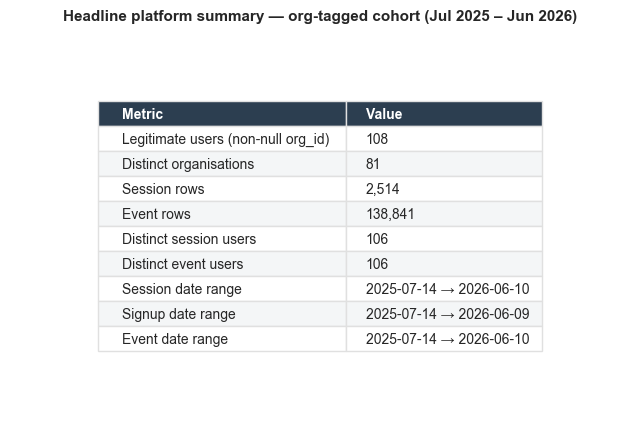

Exported: outputs/platform_00_headline_summary.csv and .png


In [2]:
# ── Load raw files ─────────────────────────────────────────────────
sessions_raw = pd.read_csv(SESSIONS_FILE)
persons_raw  = pd.read_csv(PERSONS_FILE)
# Events is now a full-period export (~232k rows, 2+ GB with the wide `properties`
# JSON column). Load only the analysis columns to keep memory and load time sane;
# add `element_text`/`element_href`/`elements_chain`/`properties` when building
# the click-level sections.
EVENTS_USECOLS = [
    "event", "event_timestamp", "distinct_id", "person_id", "auth0_org_id",
    "is_identified", "session_id", "pathname", "host",
    "browser", "os", "device_type", "country",
]
events_raw   = pd.read_csv(EVENTS_FILE, usecols=EVENTS_USECOLS, low_memory=False)

# ── Parse timestamps ───────────────────────────────────────────────
for col in ["start_timestamp", "end_timestamp"]:
    sessions_raw[col] = pd.to_datetime(sessions_raw[col], utc=True, format="ISO8601")

persons_raw["created_at"] = pd.to_datetime(persons_raw["created_at"], utc=True, format="ISO8601")
events_raw["event_timestamp"] = pd.to_datetime(events_raw["event_timestamp"], utc=True, format="ISO8601")

# ── Derive time features (sessions) ─────────────────────────────────
sessions_raw["date"]        = sessions_raw["start_timestamp"].dt.floor("D")
sessions_raw["hour"]        = sessions_raw["start_timestamp"].dt.hour
sessions_raw["day_of_week"] = sessions_raw["start_timestamp"].dt.day_name()
sessions_raw["year_month"]  = sessions_raw["start_timestamp"].dt.tz_convert(None).dt.to_period("M")

persons_raw["year_month"] = persons_raw["created_at"].dt.tz_convert(None).dt.to_period("M")
events_raw["hour"]        = events_raw["event_timestamp"].dt.hour

# ── Path → product area mapping ────────────────────────────────────
_UUID = r"[0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12}"

def simplify_path(raw_path):
    p = str(raw_path).strip().split("?")[0].split("#")[0].rstrip("/")
    if p in ("", "nan", "None", "/"):
        return "Homepage"
    if re.search(rf"/projects/{_UUID}/documents(/sources)?$", p): return "Documents"
    if re.search(rf"/projects/{_UUID}/factbook",              p): return "Results"   # Factbook renamed to Results
    if re.search(rf"/projects/{_UUID}/offer-review",          p): return "Offer Review"
    if re.search(rf"/projects/{_UUID}/results",               p): return "Results"
    if re.search(rf"/projects/{_UUID}/navi",                  p): return "Navi"
    if re.search(rf"/projects/{_UUID}/analytics",             p): return "Analytics"
    if re.search(rf"/projects/{_UUID}/agents",                p): return "Agents"
    if re.search(rf"/projects/{_UUID}/contingency-tracker",   p): return "Contingency Tracker"
    if re.search(rf"/projects/{_UUID}/factbook_table",        p): return "Results"   # folded into Results
    if p == "/projects":      return "Projects Dashboard"
    if p.startswith("/admin"):     return "Admin"
    if p.startswith("/developer"): return "Developer"
    if p.startswith("/auth"):      return "Auth"
    return "Other"

AREA_EXCLUDE = {"Admin", "Developer"}   # internal areas (admin panel / dev tools) — excluded from product-area charts

sessions_raw["entry_area"] = sessions_raw["entry_pathname"].apply(simplify_path)
sessions_raw["exit_area"]  = sessions_raw["exit_pathname"].apply(simplify_path)


# ── Working copies ────────────────────────────────────────────────
sessions = sessions_raw.copy()
persons  = persons_raw.copy()
events   = events_raw.copy()

# ── CLEANING: keep only legitimate users (verified with Parsewise) ───────────
# Parsewise confirmed that only users carrying an auth0_org_id are legitimate, real
# users (others are anonymous / test / bot traffic). Per-EVENT org tagging only began
# on 2026-03-10, but these users existed earlier — so we identify the legitimate user
# set by person_id (any user org-tagged in persons OR events) and then keep ALL of
# their history by person_id, including their pre-2026-03-10 events (which are real
# but untagged). This recovers the full ~11-month window (Jul 2025–Jun 2026) for the
# clean cohort rather than only the 3 months where the org tag is present.
# org_id is a company/tenant id (one org may hold many users) and is independent of
# free vs paid status.
_legit_ids  = set(persons.loc[persons["auth0_org_id"].notna(), "person_id"])
_legit_ids |= set(events.loc[events["auth0_org_id"].notna(), "person_id"])
_before = (len(persons), len(sessions), len(events))
persons  = persons[persons["person_id"].isin(_legit_ids)].copy()
sessions = sessions[sessions["person_id"].isin(_legit_ids)].copy()
events   = events[events["person_id"].isin(_legit_ids)].copy()
n_users = persons["person_id"].nunique()
n_orgs  = persons["auth0_org_id"].nunique()
persons["is_empty_profile"] = False          # back-compat: filter already removed non-users
print(f"Cleaning (legitimate users only — verified with Parsewise): "
      f"persons {_before[0]:,} -> {len(persons):,}, sessions {_before[1]:,} -> {len(sessions):,}, "
      f"events {_before[2]:,} -> {len(events):,}  |  {n_users} users across {n_orgs} orgs")

# ── GUARANTEE every retained user carries an org_id ──────────────────────────
# Backfill any persons row that is untagged but whose user was org-tagged in the
# event stream, then hard-assert that no retained user lacks an org_id.
_ev_org = (events.loc[events["auth0_org_id"].notna()]
           .groupby("person_id")["auth0_org_id"].agg(lambda x: x.mode().iloc[0]))
persons["auth0_org_id"] = persons["auth0_org_id"].fillna(persons["person_id"].map(_ev_org))
assert persons["auth0_org_id"].notna().all(), "A retained user has no auth0_org_id!"
print(f"Verified: all {persons['person_id'].nunique()} retained users carry an auth0_org_id "
      f"(0 missing).")
import calendar

# ââ Full calendar months present (exclude partial first/last) for monthly charts â
_allm = sorted(sessions["year_month"].unique())
_dmin, _dmax = sessions["start_timestamp"].min(), sessions["start_timestamp"].max()
FULL_MONTHS = list(_allm)
if _allm and _dmin.day != 1:
    FULL_MONTHS = [m for m in FULL_MONTHS if m != _allm[0]]                       # drop partial first month
if _allm and _dmax.day != calendar.monthrange(_dmax.year, _dmax.month)[1]:
    FULL_MONTHS = [m for m in FULL_MONTHS if m != _allm[-1]]                      # drop partial last month
FULL_MONTHS_STR = [str(m) for m in FULL_MONTHS]
MONTH_RANGE_LABEL = (f"{FULL_MONTHS_STR[0]} – {FULL_MONTHS_STR[-1]}" if FULL_MONTHS else "n/a")
print(f"Full months for monthly charts: {MONTH_RANGE_LABEL} ({len(FULL_MONTHS)} months)")


# ── Launch-milestone markers (dates match the Website Notebook timeline) ─────────
import calendar
LAUNCH_MILESTONES = [
    (pd.Timestamp("2026-02-26"), "Navi LinkedIn Launch – 26 Feb 2026",    "#2CA02C"),  # green
    (pd.Timestamp("2026-03-05"), "Parsewise Product Hunt Launch – 5 Mar 2026", "#E8B400"),  # amber/yellow
]

def _month_axis_x(ts, month_strs):
    """Fractional x-position of a date on a categorical 'YYYY-MM' month axis."""
    ms = list(month_strs)
    key = ts.strftime("%Y-%m")
    if key not in ms:
        return None
    i = ms.index(key)
    days = calendar.monthrange(ts.year, ts.month)[1]
    # Anchor each month tick to the FIRST of that month: day 1 sits on the tick,
    # later days push toward the next tick. So 5 Mar lands just right of the Mar tick.
    return i + (ts.day - 1) / days

def add_launch_markers(ax, month_strs):
    # Draw each social-media launch as a coloured dashed line; the label goes in the
    # legend/key (NOT as rotated text on the plot) — consistent convention across notebooks.
    for _ts, _label, _color in LAUNCH_MILESTONES:
        _x = _month_axis_x(_ts, month_strs)
        if _x is None:
            continue
        ax.axvline(_x, color=_color, linestyle="--", linewidth=1.6, alpha=0.95, zorder=5, label=_label)

headline_summary = pd.DataFrame({
    "Metric": [
        "Legitimate users (non-null org_id)",
        "Distinct organisations",
        "Session rows",
        "Event rows",
        "Distinct session users",
        "Distinct event users",
        "Session date range",
        "Signup date range",
        "Event date range",
    ],
    "Value": [
        f"{n_users:,}",
        f"{n_orgs:,}",
        f"{len(sessions):,}",
        f"{len(events):,}",
        f"{sessions['person_id'].nunique():,}",
        f"{events['person_id'].nunique():,}",
        f"{sessions['start_timestamp'].min().date()} → {sessions['start_timestamp'].max().date()}",
        f"{persons['created_at'].min().date()} → {persons['created_at'].max().date()}",
        f"{events['event_timestamp'].min().date()} → {events['event_timestamp'].max().date()}",
    ],
})

show(headline_summary.style.set_properties(**{"text-align": "left"}).hide(axis="index"))

# ── Export the headline summary (CSV + clean PNG for the write-up) ───────────
headline_summary.to_csv(FIG_DIR / "platform_00_headline_summary.csv", index=False)
_fig, _ax = plt.subplots(figsize=(8, 0.45 * len(headline_summary) + 0.8))
_ax.axis("off")
_tbl = _ax.table(cellText=headline_summary.values, colLabels=list(headline_summary.columns),
                 cellLoc="left", colLoc="left", loc="center")
_tbl.auto_set_font_size(False); _tbl.set_fontsize(10); _tbl.scale(1, 1.5)
for (_r, _col), _cell in _tbl.get_celld().items():
    _cell.set_edgecolor("#E0E0E0")
    if _r == 0:
        _cell.set_facecolor("#2C3E50"); _cell.set_text_props(color="white", fontweight="bold")
    elif _r % 2 == 0:
        _cell.set_facecolor("#F4F6F7")
_tbl.auto_set_column_width([0, 1])
_ax.set_title("Headline platform summary — org-tagged cohort (Jul 2025 – Jun 2026)",
              fontsize=11, fontweight="bold", pad=14)
_fig.savefig(FIG_DIR / "platform_00_headline_summary.png", dpi=200, bbox_inches="tight")
plt.show()
print("Exported: outputs/platform_00_headline_summary.csv and .png")


### What this data tells us — and what it doesn't

#### What we can infer

**From `sessions_summary` (the primary dataset):**
- How often users visit the platform and how that has changed over time
- How long users spend per session and how deeply they browse (pageview count)
- Where users enter and exit the product (entry/exit pathnames, plus `end_pathname`)
- How users arrive (referring domain / traffic source)
- Whether a session was a bounce or a meaningful visit
- Per-user return behaviour — how many sessions each user has had and when

**From `persons`:**
- When users signed up and how the registered base has grown
- Which **organisation** each user belongs to (`auth0_org_id`). In this clean export **every user carries one** — it is a company/tenant tag (not a paid-plan flag), so organisation **size** (team vs solo) is the meaningful cut, not its presence
- Per-person engagement aggregates (`click_count`, `screen_count`, `unique_pages_visited`)
- Acquisition channel and first- vs. last-touch attribution
- Resolved geography, device, OS, and browser at person level

**From `events_master` (org-tagged users, Jul 2025 – Jun 2026):**
- **What users actually click on** — `element_text` and the 100%-populated `elements_chain` identify the specific UI elements interacted with, not just a count of clicks
- The full sequence of events within a session (orderable by `session_id`, `event_timestamp`), so within-session journeys can be reconstructed
- Frustration and error signals via `$rageclick` and `$exception` events across the whole period
- Page performance via `$web_vitals`

#### What we can now do that we previously couldn't

- **Link `persons` to `sessions` and `events` directly.** All three tables now share `person_id` (and `distinct_id`), so we can compute exact per-user metrics such as signup-to-first-session lag and segment behaviour by signup cohort. The old extract kept these in separate ID spaces that could not be joined.
- **See click-level behaviour**, reconstruct within-session navigation, and quantify rageclicks/errors over the ~11-month window (Jul 2025 – Jun 2026).

#### Remaining limitations

- `element_text` is populated on roughly half of click events (PostHog only captures text where the element exposes a clear label); `elements_chain` fills the gap but must be parsed.
- We still have no explicit feature-level *outcome* data (e.g. whether a task or report was successfully completed) beyond what can be inferred from event sequences.
- `persons.distinct_id` is null for a subset of registered users who have no tracked session activity.

## 1. Session volume and timing

This section covers the most basic session-level descriptive view: how many sessions occur each month, and when those sessions happen during the week. The monthly volume chart uses raw `sessions_summary` rows before org/person filtering, so it does not rely on `auth0_org_id` validation or user matching.

month,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06
sessions,28,296,229,230,115,175,195,208,242,277,304,431,561,704,265


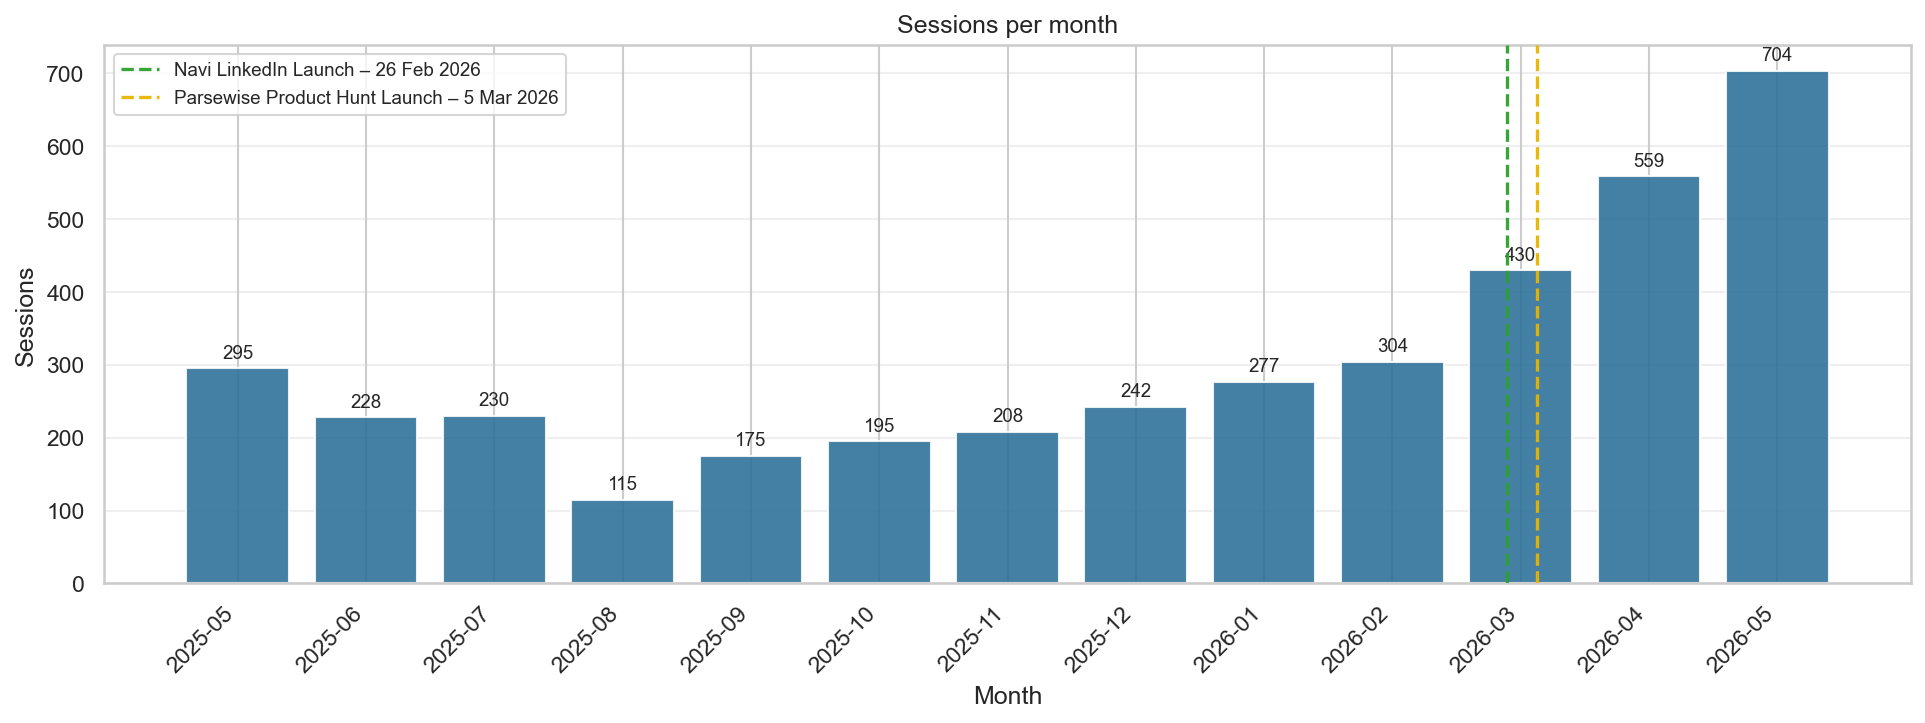

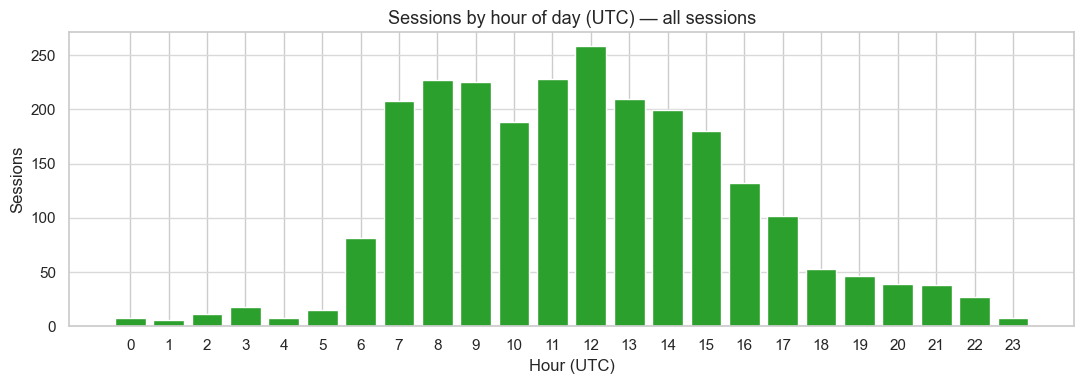

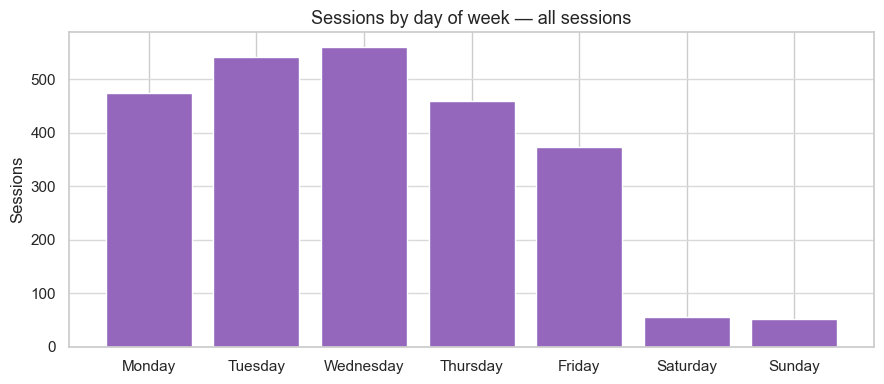

In [3]:
# Raw monthly session volume: no org/person filtering, no user-identity matching.
monthly_sessions = (
    sessions_raw.groupby("year_month")
    .agg(sessions=("session_id", "nunique"))
    .reset_index()
)
monthly_sessions["month"] = monthly_sessions["year_month"].astype(str)
monthly_sessions = monthly_sessions.iloc[1:-1].reset_index(drop=True)  # drop partial first/last months

show(monthly_sessions[["month", "sessions"]].set_index("month").T)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(monthly_sessions))
bars = ax.bar(x, monthly_sessions["sessions"], color="#2a6f97", alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(monthly_sessions["month"], rotation=45, ha="right")
ax.set_ylabel("Sessions")
ax.set_xlabel("Month")
ax.set_title("Sessions per month")
ax.grid(axis="y", alpha=0.3)
ax.bar_label(bars, labels=[f"{v:,}" for v in monthly_sessions["sessions"]], padding=3, fontsize=9)
add_launch_markers(ax, monthly_sessions["month"])
ax.legend(loc="upper left", frameon=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "platform_02_sessions_per_month.png", dpi=150, bbox_inches="tight")
plt.show()

hourly = sessions.groupby("hour").size().reset_index(name="sessions")

fig, ax = plt.subplots(figsize=(11, 4))
ax.set_axisbelow(True); ax.grid(axis="y", color="0.85")
ax.bar(hourly["hour"], hourly["sessions"], color="#2ca02c")
ax.set_title("Sessions by hour of day (UTC) — all sessions", fontsize=13)
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Sessions")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(FIG_DIR / "platform_02_hour_of_day.png", dpi=150, bbox_inches="tight")
plt.show()

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = sessions.groupby("day_of_week").size().reindex(dow_order).reset_index(name="sessions")

fig, ax = plt.subplots(figsize=(9, 4))
ax.set_axisbelow(True); ax.grid(axis="y", color="0.85")
ax.bar(dow["day_of_week"], dow["sessions"], color="#9467bd")
ax.set_title("Sessions by day of week — all sessions", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Sessions")
fig.tight_layout()
fig.savefig(FIG_DIR / "platform_03_day_of_week.png", dpi=150, bbox_inches="tight")
plt.show()


**Findings — session volume and timing:**

- Raw session volume rises materially across the observed period, from **175 sessions in September 2025** to **704 sessions in May 2026**. **April 2025** and **June 2026** are partial months, so they should not be read as full-month demand.
- Dashed lines mark the **Navi LinkedIn launch (26 Feb 2026)** and **Navi Product Hunt launch (5 Mar 2026)**, so the post-launch session trend can be read against those events.
- This is **usage volume, not retention**. It avoids the org-tagging survivor filter by using raw session rows, but it does not say whether the same users came back month after month.
- Activity ramps from **06:00 UTC (81 sessions)** and **peaks at 12:00 UTC (258 sessions)**, staying elevated through the early afternoon — a **UK/European and US East-Coast** professional pattern.
- **Weekday usage dominates overwhelmingly:** Wednesday (560), Tuesday (541) and Monday (474) are busiest, while Saturday (55) and Sunday (52) are minimal — a clear B2B / working-week rhythm.

## 2. Geography & device demographics

Profiled users (with resolved geography/device): 106 (98.1% of registered users)


,Country,Users
1,United Kingdom,21
2,India,17
3,United States,14
4,Switzerland,12
5,Germany,9
6,Finland,5
7,Austria,3
8,Thailand,3
9,China,2
10,Pakistan,2


,Device,Users
1,Desktop,103
2,Mobile,3


,OS,Users
1,Mac OS X,54
2,Windows,45
3,Linux,3
4,Android,2
5,iOS,1
6,Chrome OS,1


,Browser,Users
1,Chrome,91
2,Microsoft Edge,9
3,Safari,4
4,Chrome iOS,1
5,Firefox,1


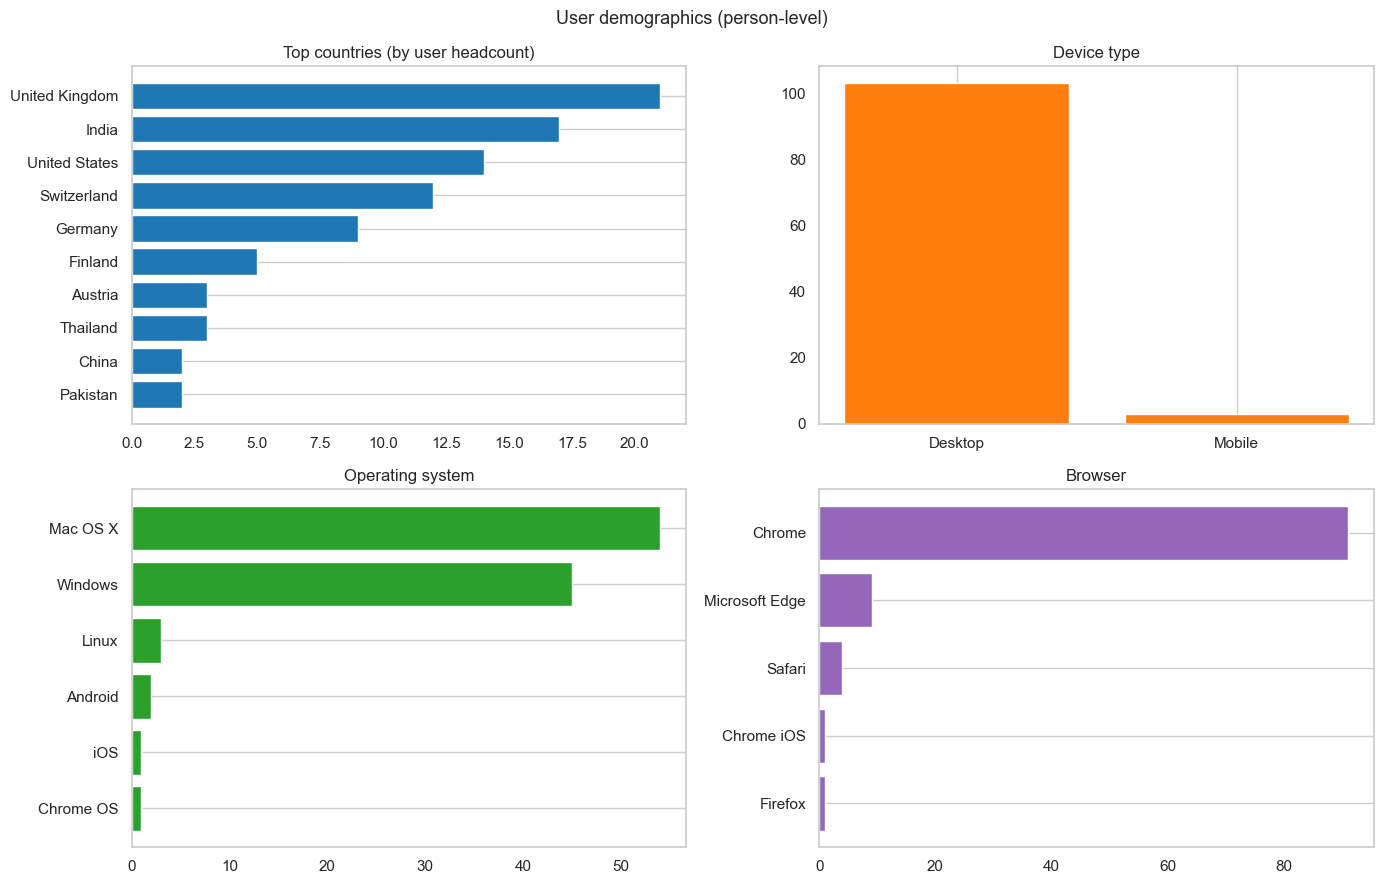

,Country,Events,% of events
1,United Kingdom,59354,42.7
2,Switzerland,33887,24.4
3,Germany,18407,13.3
4,Spain,8522,6.1
5,Finland,3860,2.8
6,Romania,2361,1.7
7,India,2219,1.6
8,United States,2194,1.6
9,Austria,1693,1.2
10,Belgium,1063,0.8


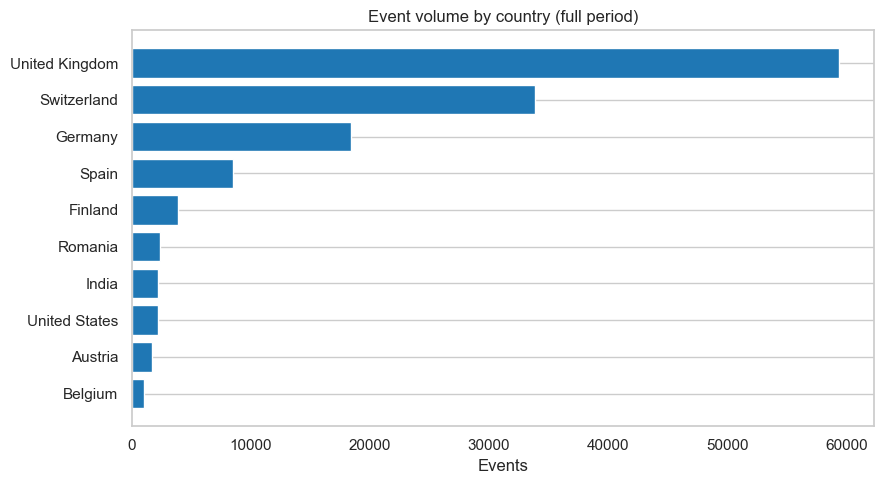

In [4]:
profiled = persons[persons["country"].notna()].copy()
print(f"Profiled users (with resolved geography/device): {len(profiled):,} "
      f"({len(profiled)/len(persons)*100:.1f}% of registered users)")

geo  = profiled["country"].value_counts().head(10).rename_axis("Country").reset_index(name="Users")
dev  = profiled["device_type"].value_counts().rename_axis("Device").reset_index(name="Users")
osys = profiled["operating_system"].value_counts().head(6).rename_axis("OS").reset_index(name="Users")
brow = profiled["browser"].value_counts().head(6).rename_axis("Browser").reset_index(name="Users")
show(geo); show(dev); show(osys); show(brow)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0,0].barh(geo["Country"][::-1], geo["Users"][::-1], color="#1f77b4")
axes[0,0].set_title("Top countries (by user headcount)"); axes[0,0].grid(axis="x")
axes[0,1].bar(dev["Device"], dev["Users"], color="#ff7f0e")
axes[0,1].set_title("Device type"); axes[0,1].grid(axis="y")
axes[1,0].barh(osys["OS"][::-1], osys["Users"][::-1], color="#2ca02c")
axes[1,0].set_title("Operating system"); axes[1,0].grid(axis="x")
axes[1,1].barh(brow["Browser"][::-1], brow["Users"][::-1], color="#9467bd")
axes[1,1].set_title("Browser"); axes[1,1].grid(axis="x")
fig.suptitle("User demographics (person-level)", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "platform_38_demographics.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Event VOLUME by country (headcount ≠ activity) ───────────────────────────
events_by_country = (
    events["country"].fillna("Unknown").value_counts().head(10)
    .rename_axis("Country").reset_index(name="Events")
)
events_by_country["% of events"] = (events_by_country["Events"] / len(events) * 100).round(1)
show(events_by_country)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(events_by_country["Country"][::-1], events_by_country["Events"][::-1], color="#1f77b4")
ax.set_title("Event volume by country (full period)")
ax.set_xlabel("Events"); ax.grid(axis="x")
fig.tight_layout()
fig.savefig(FIG_DIR / "platform_39_events_by_country.png", dpi=150, bbox_inches="tight")
plt.show()


**Findings — geography & device demographics:**

- By **user headcount** (106 profiled) the base is led by the **United Kingdom (21), India (17), United States (14), Switzerland (12) and Germany (9)**, with a notable APAC presence (India, Thailand, China).
- By **event volume the picture flips**: activity concentrates in the **United Kingdom (42.7% of events) and Switzerland (24.4%)** — two-thirds of all activity between them — then Germany (13.3%). **India, despite the second-largest headcount, generates little activity.** So a small number of **UK/Swiss accounts drive disproportionate usage** relative to their share of users (the events-by-country chart above).
- **Device usage is overwhelmingly Desktop (103 of 106, ~97%)**; **OS splits Mac OS X (54) vs Windows (45)** — a professional desktop tool. *(Note: `device_type` only distinguishes Desktop / Mobile / Tablet — it cannot separate laptop from desktop.)*

## 3. Session behaviour: duration and depth

Session duration and pageview depth describe how deeply users engage with the platform in a single session. The distribution is highly right-skewed, so median values are more representative of the typical user than the mean. *(Bounce is analysed separately in Section 10.5.)*

,Duration bucket,Sessions,% sessions
1,0–10s (instant),155,6.8
2,10–60s (quick),259,11.4
3,1–5 min,473,20.9
4,5–15 min,374,16.5
5,15 min–1 hr,691,30.5
6,1 hr+,311,13.7


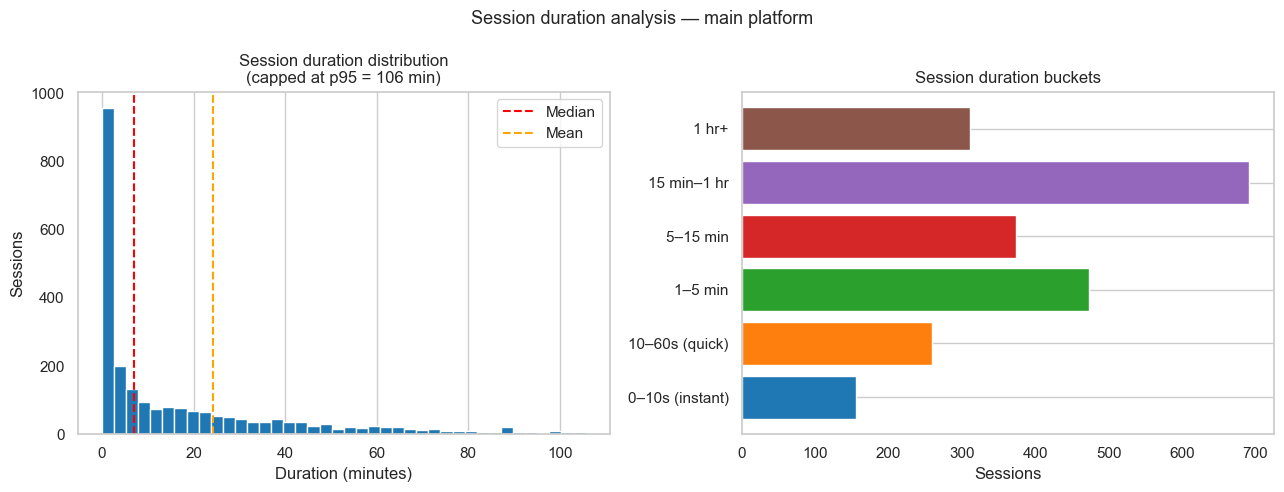

In [5]:
# ── Duration distribution ─────────────────────────────────────────────────────
p95_dur = sessions["session_duration_seconds"].quantile(0.95)
sessions_capped = sessions[sessions["session_duration_seconds"] <= p95_dur].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(
    sessions_capped["session_duration_seconds"] / 60,
    bins=40, color="#1f77b4", edgecolor="white"
)
axes[0].set_title(f"Session duration distribution\n(capped at p95 = {p95_dur/60:.0f} min)")
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_ylabel("Sessions")
axes[0].axvline(
    sessions["session_duration_seconds"].median() / 60,
    color="red", linestyle="--", linewidth=1.5, label="Median"
)
axes[0].axvline(
    sessions["session_duration_seconds"].mean() / 60,
    color="orange", linestyle="--", linewidth=1.5, label="Mean"
)
axes[0].legend()
axes[0].grid(axis="y")

# ── Duration buckets ──────────────────────────────────────────────────────────
dur_bins   = [0, 10, 60, 300, 900, 3600, 999999]
dur_labels = ["0–10s (instant)", "10–60s (quick)", "1–5 min", "5–15 min", "15 min–1 hr", "1 hr+"]
sessions["duration_bucket"] = pd.cut(
    sessions["session_duration_seconds"], bins=dur_bins, labels=dur_labels
)
dur_dist = sessions["duration_bucket"].value_counts().sort_index().reset_index()
dur_dist.columns = ["Duration bucket", "Sessions"]
dur_dist["% sessions"] = (dur_dist["Sessions"] / dur_dist["Sessions"].sum() * 100).round(1)
show(dur_dist)

axes[1].barh(dur_dist["Duration bucket"], dur_dist["Sessions"], color=BRAND_PALETTE[:6])
axes[1].set_title("Session duration buckets")
axes[1].set_xlabel("Sessions")
axes[1].grid(axis="x")

fig.suptitle("Session duration analysis — main platform", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "platform_07_session_duration.png", dpi=150, bbox_inches="tight")
plt.show()

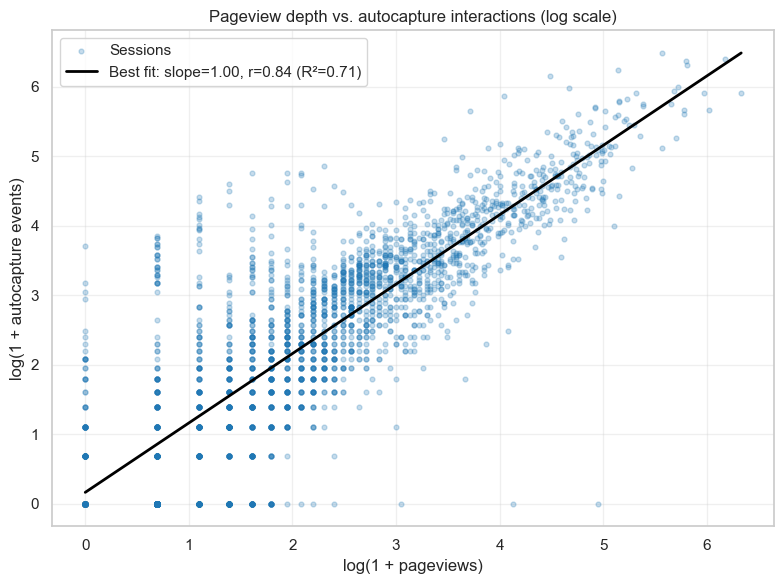

In [6]:
# ── Pageview depth vs. autocapture scatter ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    np.log1p(sessions["pageview_count"]),
    np.log1p(sessions["autocapture_count"]),
    alpha=0.25, s=12, color="#1f77b4", label="Sessions"
)
# ── Line of best fit (OLS on log-log data, all sessions) ─────────────────────
lx = np.log1p(sessions["pageview_count"]).values
ly = np.log1p(sessions["autocapture_count"]).values
slope, intercept = np.polyfit(lx, ly, 1)
r = np.corrcoef(lx, ly)[0, 1]
xs = np.linspace(lx.min(), lx.max(), 100)
ax.plot(xs, slope * xs + intercept, color="black", linewidth=2,
        label=f"Best fit: slope={slope:.2f}, r={r:.2f} (R²={r**2:.2f})")

ax.set_title("Pageview depth vs. autocapture interactions (log scale)")
ax.set_xlabel("log(1 + pageviews)")
ax.set_ylabel("log(1 + autocapture events)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "platform_08_pageview_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


**Findings — session behaviour:**

- **Median session duration is 420 s (7.0 min)** versus a **mean of 1,459 s (24.3 min)** — a wide gap driven by a long right tail of deep working sessions, so the median is the better "typical session" figure.
- By duration bucket the **largest group is 15 min–1 hr (30.5%)**, with a further **13.7% over an hour** — a substantial share of deep, task-focused work. About **18%** of sessions last under a minute (0–10 s: 6.8%, 10–60 s: 11.4%) — quick check-ins.
- The **pageview-vs-interaction scatter** shows a tight log-log relationship (slope ≈ 1.0, R² ≈ 0.71): deeper sessions generate proportionally more interactions.

*(Bounce rates by landing area are covered in Section 10.5.)*

## 4. Session quality

Counting sessions says nothing about whether a visit was *substantive*. This section measures session **quality** two ways:
1. a **"meaningful session" rate** — a deliberately strict bar, benchmarked against the industry-standard **GA4 "engaged session"** — tracked month to month; and
2. **engagement by product area, measured by time actually spent per visit** (dwell time, not where the session started), to see which areas hold users' attention.

GA4-style 'engaged session' rate (industry standard, lenient): 88.7%
Strict 'meaningful / deep session' rate (used in this notebook): 57.4%


,year_month_str,total,meaningful,meaningful_pct
1,2025-07,3,2,66.7
2,2025-09,35,25,71.4
3,2025-10,121,70,57.9
4,2025-11,155,98,63.2
5,2025-12,134,74,55.2
6,2026-01,130,81,62.3
7,2026-02,197,132,67.0
8,2026-03,290,173,59.7
9,2026-04,545,308,56.5
10,2026-05,647,348,53.8


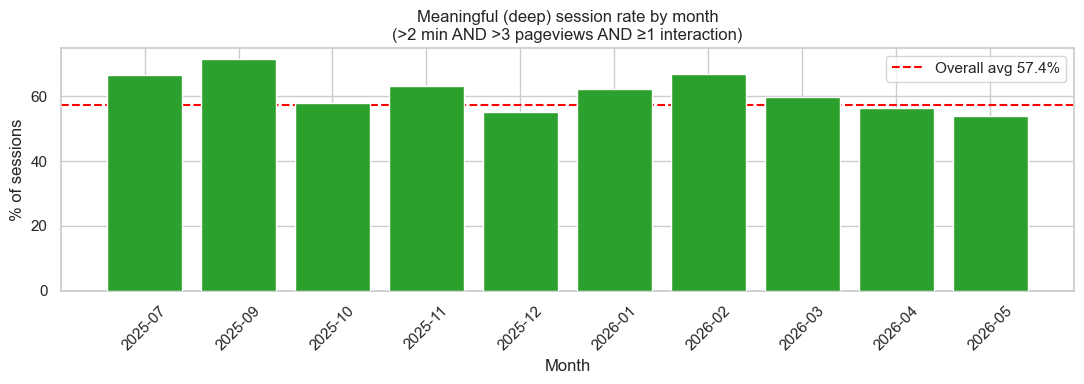

In [7]:
# ── Industry benchmark: GA4 "engaged session" (OR logic, low bar) ─────────────
# GA4 standard: a session lasting > 10s, OR with >= 2 pageviews, OR >= 1 key event.
sessions["engaged_ga4"] = (
    (sessions["session_duration_seconds"] > 10) |
    (sessions["pageview_count"] >= 2) |
    (sessions["autocapture_count"] >= 1)
).astype(int)

# ── This notebook's stricter "meaningful (deep) session" — ALL must hold ──────
sessions["meaningful"] = (
    (sessions["session_duration_seconds"] > 120) &   # > 2 minutes
    (sessions["pageview_count"] > 3) &                # > 3 pageviews
    (sessions["autocapture_count"] > 0)               # >= 1 interaction
).astype(int)

overall_pct = sessions["meaningful"].mean() * 100
print(f"GA4-style 'engaged session' rate (industry standard, lenient): {sessions['engaged_ga4'].mean()*100:.1f}%")
print(f"Strict 'meaningful / deep session' rate (used in this notebook): {overall_pct:.1f}%")

monthly_quality = (
    sessions[sessions["year_month"] < "2026-06"]
    .groupby("year_month")
    .agg(total=("session_id", "count"), meaningful=("meaningful", "sum"))
    .reset_index()
)
monthly_quality["meaningful_pct"] = (monthly_quality["meaningful"] / monthly_quality["total"] * 100).round(1)
monthly_quality["year_month_str"] = monthly_quality["year_month"].astype(str)
show(monthly_quality[["year_month_str", "total", "meaningful", "meaningful_pct"]])

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(monthly_quality["year_month_str"], monthly_quality["meaningful_pct"], color="#2ca02c", zorder=3)
ax.axhline(overall_pct, color="red", linestyle="--", linewidth=1.5, label=f"Overall avg {overall_pct:.1f}%")
ax.set_title("Meaningful (deep) session rate by month\n(>2 min AND >3 pageviews AND ≥1 interaction)")
ax.set_xlabel("Month"); ax.set_ylabel("% of sessions")
ax.tick_params(axis="x", rotation=45); ax.legend(); ax.grid(axis="y", zorder=0)
fig.tight_layout(); fig.savefig(FIG_DIR / "platform_13_meaningful_sessions.png", dpi=150, bbox_inches="tight"); plt.show()

,area,visiting_sessions,min_per_visit
1,Factbook,589,21.0
2,Contingency Tracker,41,12.5
3,Agents,1244,10.1
4,Offer Review,153,9.5
5,Results,732,7.9
6,Navi,1232,5.2
7,Documents,1222,4.7
8,Projects Dashboard,1964,4.1
9,Other,721,4.0


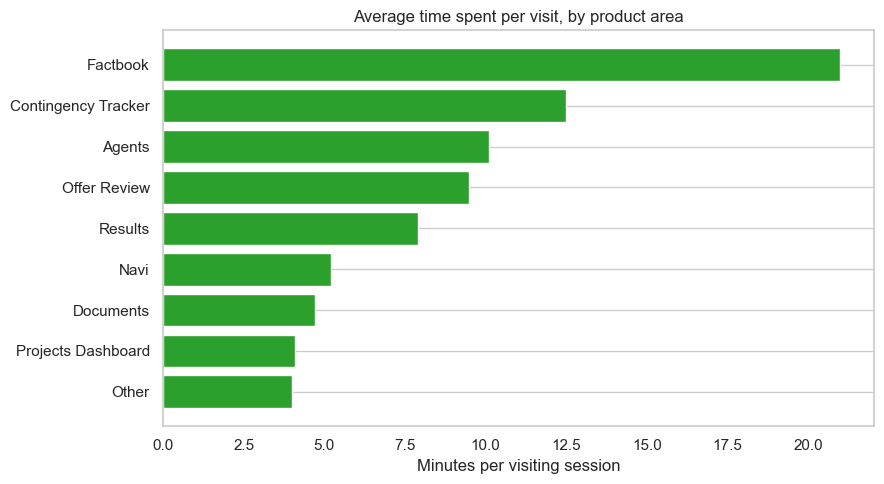

In [8]:
# ── Engagement by area, by TIME SPENT (not entry) ────────────────────────────
# "Meaningful %" and "bounce" are whole-session properties, so they can't be
# attributed to the areas where time was spent. Instead we measure, per area, the
# AVERAGE time a session actually spends there when it visits — a time-based
# engagement signal that doesn't depend on where the session started.
_ev = events[["session_id", "event_timestamp", "pathname"]].copy()
_ev["area"] = _ev["pathname"].apply(simplify_path)
_ev = _ev.sort_values(["session_id", "event_timestamp"])
_ev["dwell_s"] = (
    _ev.groupby("session_id")["event_timestamp"].shift(-1) - _ev["event_timestamp"]
).dt.total_seconds().clip(upper=1800)

area_engagement = (
    _ev.groupby("area")
    .agg(visiting_sessions=("session_id", "nunique"), total_min=("dwell_s", lambda x: x.sum() / 60))
    .reset_index()
)
area_engagement["min_per_visit"] = (area_engagement["total_min"] / area_engagement["visiting_sessions"]).round(1)
area_engagement = (area_engagement[(area_engagement["visiting_sessions"] >= 10)
                    & (~area_engagement["area"].isin(AREA_EXCLUDE))]   # drop tiny-n + internal areas
                   .sort_values("min_per_visit", ascending=False).reset_index(drop=True))
show(area_engagement[["area", "visiting_sessions", "min_per_visit"]])

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(area_engagement["area"][::-1], area_engagement["min_per_visit"][::-1], color="#2ca02c")
ax.set_title("Average time spent per visit, by product area")
ax.set_xlabel("Minutes per visiting session"); ax.grid(axis="x")
fig.tight_layout()
fig.savefig(FIG_DIR / "platform_14_engagement_by_area.png", dpi=150, bbox_inches="tight")
plt.show()


**Findings — session quality:**

- **Overall engagement is high.** By GA4's lenient "engaged session" definition **88.7%** of sessions qualify; by this notebook's stricter "meaningful / deep session" bar (>2 min AND >3 pageviews AND ≥1 interaction) **57.4%** clear it — strong for a B2B tool. The meaningful rate is stable month to month (~55–71%).
- **Measured by time actually spent per visit** (not where the session started), the stickiest areas are **Factbook (21.0 min/visit) and Contingency Tracker (12.5)** — deep reading/analysis surfaces — then **Agents (10.1)** and Offer Review (9.5). Factbook stands out: users linger there far longer per visit than anywhere else.
- **The Projects Dashboard hub has the *shortest* time per visit (4.1 min) despite the most visits (1,964)** — a pass-through, not a destination. **Documents is similar (4.7 min/visit across 1,222 visits): visited often but briefly**, even though it accumulates a lot of total time (Section 5).
- **Decision implication:** the deep value sits in Factbook and Agents (long, focused visits); the dashboard is transit. Onboarding should route users into those working surfaces quickly.

> **Source — industry benchmark.** GA4 "engaged session" (>10 s, **or** ≥2 pageviews, **or** ≥1 key event), Google Analytics Help, *"[GA4] Session"* — https://support.google.com/analytics/answer/12798876. The stricter "meaningful session" bar is a custom definition. *(Bounce by landing area is covered in Section 10.5.)*

## 5. Event-stream analysis (full period)

The events export covers the clean **~11-month window (10 Jul 2025 – 10 Jun 2026)** with **138,841 events** from org-tagged users, carrying multiple browsers, operating systems, devices, and countries.

> All events are from identified (signed-in) users (`is_identified = 1`), as expected for the authenticated product.

,Event type,Count,% of events
1,$autocapture,70125,50.5
2,$pageview,50607,36.4
3,$web_vitals,11724,8.4
4,$set,3712,2.7
5,$exception,1525,1.1
6,$rageclick,795,0.6
7,$groupidentify,353,0.3


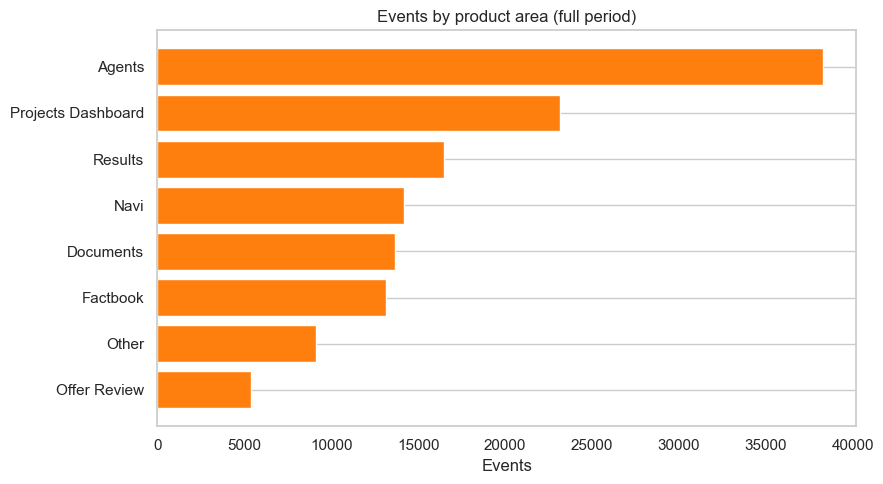

In [9]:
event_types = events["event"].value_counts().reset_index()
event_types.columns = ["Event type", "Count"]
event_types["% of events"] = (event_types["Count"] / event_types["Count"].sum() * 100).round(1)
show(event_types)

# ── Events by product area (full period) ──────────────────────────────────────
events["path_area"] = events["pathname"].apply(simplify_path)
_pa = events["path_area"].value_counts()
_pa = _pa[~_pa.index.isin(AREA_EXCLUDE)]
path_area_counts = _pa.head(8).reset_index()
path_area_counts.columns = ["Product area", "Events"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(path_area_counts["Product area"][::-1], path_area_counts["Events"][::-1], color="#ff7f0e")
ax.set_title("Events by product area (full period)")
ax.set_xlabel("Events"); ax.grid(axis="x")
fig.tight_layout()
fig.savefig(FIG_DIR / "platform_10_events_by_area.png", dpi=150, bbox_inches="tight")
plt.show()


**Findings — event stream (full period):**

- The **138,841 events** break down as **`$autocapture` 50.5% (70,125)**, **`$pageview` 36.4% (50,607)**, **`$web_vitals` 8.4% (11,724)**, **`$set` 2.7%**, **`$exception` 1.1% (1,525)**, **`$rageclick` 0.6% (795)**.
- **Agents is by far the most event-heavy area (38,282 events)**, ahead of Projects Dashboard (23,173), Documents (18,402), Results (16,475), Navi (14,162) and Factbook (13,171) — Agents is where *interaction* concentrates.

*(Device and geography are covered in Section 2.)*

## 6. Feature adoption

Two views of how usage spreads across the product: an entry-to-exit **flow matrix** of the most common session journeys, and a **feature-reach** metric showing what share of **sessions** include each area.

Top 15 entry → exit journeys:


,journey,sessions
1,Projects Dashboard → Projects Dashboard,470
2,Documents → Factbook,152
3,Factbook → Factbook,146
4,Projects Dashboard → Agents,144
5,Projects Dashboard → Navi,121
6,Offer Review → Offer Review,107
7,Projects Dashboard → Documents,99
8,Projects Dashboard → Factbook,90
9,Agents → Agents,79
10,Projects Dashboard → Results,78


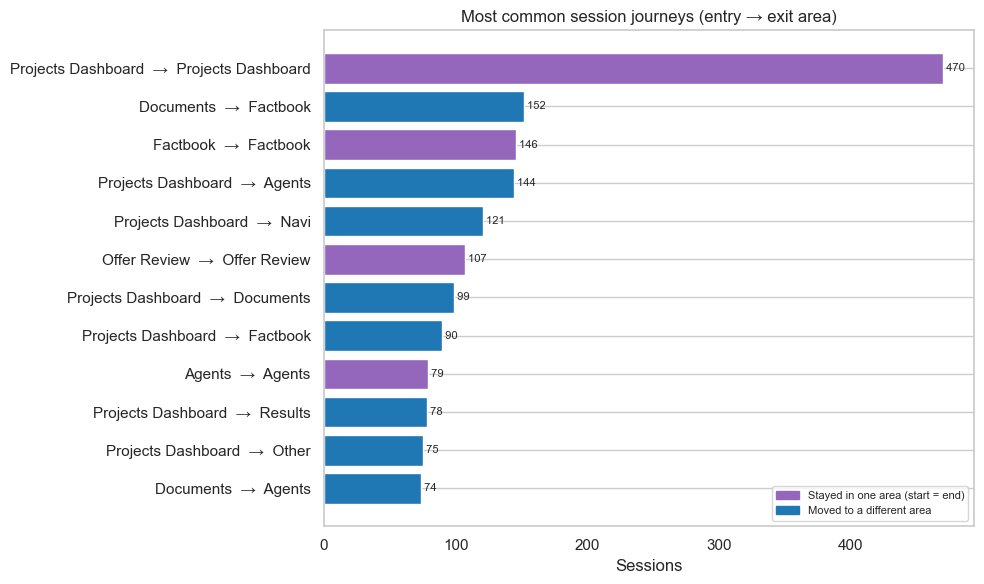

In [10]:
# ── Most common session journeys (entry area → exit area) ─────────────────────
flow_matrix = (
    sessions[~sessions["entry_area"].isin(AREA_EXCLUDE)
             & ~sessions["exit_area"].isin(AREA_EXCLUDE)]    # drop internal admin/dev areas
    .groupby(["entry_area", "exit_area"]).size()
    .reset_index(name="sessions").sort_values("sessions", ascending=False)
)
flow_matrix["journey"]   = flow_matrix["entry_area"] + "  →  " + flow_matrix["exit_area"]
flow_matrix["same_area"] = flow_matrix["entry_area"] == flow_matrix["exit_area"]

print("Top 15 entry → exit journeys:")
show(flow_matrix[["journey", "sessions"]].head(15).reset_index(drop=True))

# A ranked bar chart is far clearer than a 13x13 matrix dominated by one cell.
top = flow_matrix.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#9467bd" if sa else "#1f77b4" for sa in top["same_area"]]
ax.barh(top["journey"], top["sessions"], color=colors)
for y, v in enumerate(top["sessions"]):
    ax.text(v, y, f" {v:,}", va="center", fontsize=8)
ax.set_title("Most common session journeys (entry → exit area)")
ax.set_xlabel("Sessions"); ax.grid(axis="x")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#9467bd", label="Stayed in one area (start = end)"),
                   Patch(color="#1f77b4", label="Moved to a different area")], fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / "platform_15_top_journeys.png", dpi=150, bbox_inches="tight")
plt.show()

#### Feature reach — % of sessions that include each area

The share of all **2,514 sessions** whose journey touches each area (any event in the session is in that area). This is session-weighted — frequent areas show up in many sessions — and complements the per-visit *time* view in Section 4.

**Navi is shown exposure-adjusted** (red diamond): because Navi only went live in **January 2026**, sessions before then couldn't include it, so the full-window figure understates it. Re-based on the **2,066 sessions from Jan 2026 onward**, Navi's reach rises from **49% to 59%**. Other areas were available throughout, so they stay on the full denominator.

,Product area,% of sessions including area
1,Projects Dashboard,78.1
2,Agents,49.5
3,Navi,49.0
4,Documents,48.6
5,Results,29.1
6,Other,28.7
7,Factbook,23.4
8,Offer Review,6.1
9,Contingency Tracker,1.6


Navi reach — full window: 49.0% of all 2,514 sessions; exposure-adjusted (Jan-2026+ sessions, n=2,066): 59.3%


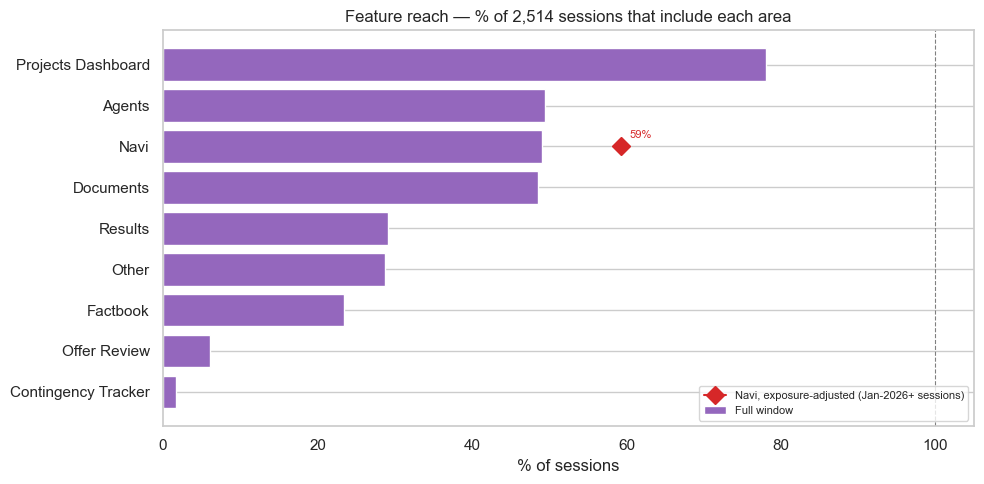

In [11]:
# Feature reach: % of SESSIONS whose journey includes each area
total_sessions = sessions["session_id"].nunique()
ev_area = events[["session_id", "pathname"]].copy()
ev_area["area"] = ev_area["pathname"].apply(simplify_path)
session_reach = (
    ev_area.groupby("area")["session_id"].nunique() / total_sessions * 100
).sort_values(ascending=False)
session_reach = session_reach[~session_reach.index.isin(AREA_EXCLUDE)]   # drop internal areas

# Navi exposure adjustment: Navi only went live Jan 2026, so pre-Jan sessions could
# not include it. Re-base Navi on sessions from Jan 2026 onward (its available window).
postjan_sessions = set(sessions.loc[sessions["start_timestamp"] >= pd.Timestamp("2026-01-01", tz="UTC"), "session_id"])
navi_sessions    = set(ev_area.loc[ev_area["area"] == "Navi", "session_id"])
navi_adj = len(navi_sessions & postjan_sessions) / len(postjan_sessions) * 100

show(session_reach.round(1).rename_axis("Product area").reset_index(name="% of sessions including area"))
print(f"Navi reach — full window: {session_reach['Navi']:.1f}% of all {total_sessions:,} sessions; "
      f"exposure-adjusted (Jan-2026+ sessions, n={len(postjan_sessions):,}): {navi_adj:.1f}%")

fig, ax = plt.subplots(figsize=(10, 5))
order = list(session_reach.index[::-1])
ax.barh(order, [session_reach[a] for a in order], color="#9467bd", label="Full window")
_ny = order.index("Navi")
ax.plot(navi_adj, _ny, marker="D", color="#d62728", markersize=9, zorder=5,
        label="Navi, exposure-adjusted (Jan-2026+ sessions)")
ax.annotate(f"{navi_adj:.0f}%", (navi_adj, _ny), xytext=(6, 6), textcoords="offset points",
            fontsize=8, color="#d62728")
ax.axvline(100, color="grey", linestyle="--", linewidth=0.8)
ax.set_title(f"Feature reach — % of {total_sessions:,} sessions that include each area")
ax.set_xlabel("% of sessions"); ax.grid(axis="x"); ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / "platform_50_session_reach.png", dpi=150, bbox_inches="tight")
plt.show()


**Findings — feature adoption:**

- The **most common journey is Projects Dashboard → Projects Dashboard (470 sessions)**. **Documents → Factbook (152)** and **Factbook → Factbook (146)** are the leading feature-focused sessions.
- Cross-area flows radiate from the hub: **Projects Dashboard → Agents (144), → Navi (121), → Documents (99)** — a clear hub-and-spoke pattern.
- **Feature reach** — % of the **2,514 sessions** whose journey includes each area: **Projects Dashboard 78%**, then **Agents 49%, Navi 49%, Documents 49%**, Results 29%, Factbook 23%, with a niche tail (Offer Review 6%, Contingency Tracker 2%). *(Internal Admin / Developer areas are excluded throughout as they are operator-only, not user-facing.)* **Navi rises to 59% once exposure-adjusted** to its Jan-2026+ availability window (it couldn't appear in earlier sessions).
- Note **Factbook appears in 23% of sessions yet is concentrated in a small set of power users** — the few who use it return to it repeatedly (it also has the longest time-per-visit, Section 4). The hub is in 78% of sessions (not all — deep-linked sessions skip it).

In [12]:
# ── Shared click-level loader (used by later sections) ───────────────────────
# Builds the `clicks` and `ev` dataframes consumed downstream (team-vs-solo
# engagement, association-rule mining). Retained as plumbing after the
# click/CTA analysis section was removed.
# ── Load click-level columns from the full events export ─────────────────────
CLICK_USECOLS = ["event", "event_type", "pathname", "person_id",
                 "element_text", "element_href", "elements_chain"]
ev = pd.read_csv(EVENTS_FILE, usecols=CLICK_USECOLS, low_memory=False)
ev = ev[ev["person_id"].isin(_legit_ids)]            # legitimate (org-tagged) users only

autocapture = ev[ev["event"] == "$autocapture"].copy()
autocapture["area"] = autocapture["pathname"].apply(simplify_path)   # simplify_path from cell 4

clicks = autocapture[autocapture["event_type"] == "click"].copy()

# ── elements_chain parser: recover a label when element_text is blank ─────────
_TAG_LABELS = {
    "button": "‹unlabelled button›", "textarea": "‹text area›", "input": "‹input field›",
    "select": "‹dropdown›", "td": "‹table cell›", "tr": "‹table row›",
    "svg": "‹icon›", "path": "‹icon›", "circle": "‹icon›", "img": "‹image›",
    "div": "‹container›", "a": "‹link›", "span": "‹text›", "p": "‹text›",
}

def label_from_chain(chain):
    """Return a human label for the clicked (leading) element of an elements_chain."""
    seg = str(chain).split(";")[0]
    # 1) explicit text on the element
    m = re.search(r':text="([^"]+)"', seg)
    if m:
        return m.group(1).strip()
    # 2) accessibility / title attributes
    for attr in ("aria-label", "title"):
        m = re.search(rf'attr__{attr}="([^"]+)"', seg)
        if m:
            return m.group(1).strip()
    # 3) fall back to a readable element-type label
    tag = re.match(r"^([a-zA-Z0-9]+)", seg)
    tag = tag.group(1) if tag else "unknown"
    return _TAG_LABELS.get(tag, f"‹{tag}›")

# Unified click label: element_text where present, else recovered from the chain
clicks["label"] = clicks["element_text"]
blank_mask = clicks["label"].isna()
clicks.loc[blank_mask, "label"] = clicks.loc[blank_mask, "elements_chain"].apply(label_from_chain)

print(f"Autocapture events : {len(autocapture):,}")
print(f"  clicks           : {(autocapture['event_type']=='click').sum():,}")
print(f"  changes (typing) : {(autocapture['event_type']=='change').sum():,}")
print(f"  submits          : {(autocapture['event_type']=='submit').sum():,}")
print(f"element_text filled on clicks : {clicks['element_text'].notna().mean()*100:.1f}%")

Autocapture events : 70,125
  clicks           : 64,714
  changes (typing) : 5,063
  submits          : 348
element_text filled on clicks : 63.1%


## 7. Within-session journeys

This section focuses on the **shape of real session journeys**, not exhaustive transition detail. Using the full `$pageview` stream, each session is reduced to an ordered sequence of **product areas visited**. Consecutive repeats are collapsed so the emphasis stays on movement between areas rather than page-by-page noise.

Pages are mapped to areas with a **refined ruleset** (`journey_area`, below) that resolves surfaces the global mapper dropped into a catch-all `Other` — most importantly **document detail pages** (which count as *Documents*) and **project roots** (*Project Home*). Internal pages (Admin / Developer), **bespoke few-customer surfaces** (Offer Review, Contingency Tracker, Custom UIs, Reinsurance — each used by only 2–3 of 79 orgs) and a small unclassified residual are excluded, so every node is a genuine, broadly-used product area.

Two concise views follow:
1. **Session-journey summary** — how broad sessions are and what the common journey shapes look like
2. **Sankey diagram** — the product-area paths at **steps 1 to 4** (no `Other` bucket)

In [13]:
# ── Reconstruct ordered page sequences per session ───────────────────────────
# journey_area(): a journey-LOCAL refinement of the global simplify_path(). The
# global Documents regex is anchored ("/documents$"), so document *detail* pages
# (/projects/<id>/documents/<docid>) and the project root (/projects/<id>) fell
# into "Other" — together ~2,600 pageviews, which made "Other" the 3rd-largest
# area and polluted this Sankey. We map those to their real areas and add the
# lower-volume product surfaces. Scope: this section only — global simplify_path()
# is unchanged, so other sections' figures are unaffected.
def journey_area(raw_path):
    p = str(raw_path).strip().split("?")[0].split("#")[0].rstrip("/")
    if p in ("", "nan", "None", "/"):                                        return "Homepage"
    if re.search(rf"/projects/{_UUID}/documents(/sources)?(/{_UUID})?$", p): return "Documents"
    if re.search(rf"/projects/{_UUID}/factbook",            p):              return "Factbook"
    if re.search(rf"/projects/{_UUID}/offer-review",        p):              return "Offer Review"
    if re.search(rf"/projects/{_UUID}/results",             p):              return "Results"
    if re.search(rf"/projects/{_UUID}/navi",                p):              return "Navi"
    if re.search(rf"/projects/{_UUID}/analytics",           p):              return "Analytics"
    if re.search(rf"/projects/{_UUID}/agents",              p):              return "Agents"
    if re.search(rf"/projects/{_UUID}/contingency-tracker", p):              return "Contingency Tracker"
    if re.search(rf"/projects/{_UUID}/factbook_table",      p):              return "Factbook Table"
    if re.search(rf"/projects/{_UUID}/reinsurance",         p):              return "Reinsurance"
    if re.search(rf"/projects/{_UUID}/custom-uis",          p):              return "Custom UIs"
    if re.search(rf"/projects/{_UUID}$",                    p):              return "Project Home"
    if p == "/projects":                                                     return "Projects Dashboard"
    if p.startswith("/onboarding"):                                          return "Onboarding"
    if p.startswith("/billing") or p.startswith("/subscription"):            return "Billing"
    if p.startswith("/admin"):                                               return "Admin"
    if p.startswith("/developer"):                                           return "Developer"
    if p.startswith("/auth"):                                                return "Auth"
    return "Other"

# Dropped from the journey/diagnostics views so every node is a genuine, broadly-used
# product area: internal tooling (Admin/Developer), the unclassified residual (Other),
# and bespoke few-customer surfaces (Offer Review, Contingency Tracker, Custom UIs,
# Reinsurance — each used by only 2-3 of 79 orgs, so not general product areas).
JOURNEY_EXCLUDE = {"Admin", "Developer", "Other",
                   "Offer Review", "Contingency Tracker", "Custom UIs", "Reinsurance"}

pv = pd.read_csv(EVENTS_FILE,
                 usecols=["event", "event_timestamp", "session_id", "pathname", "distinct_id", "person_id"],
                 low_memory=False)
pv = pv[pv["person_id"].isin(_legit_ids)]             # legitimate (org-tagged) users only
pv = pv[pv["event"] == "$pageview"].copy()
pv["event_timestamp"] = pd.to_datetime(pv["event_timestamp"], utc=True, format="ISO8601")
pv["area"] = pv["pathname"].apply(journey_area)
pv = pv[~pv["area"].isin(JOURNEY_EXCLUDE)]            # drop internal + unclassified pages
pv = pv.sort_values(["session_id", "event_timestamp"])

def collapse(areas):
    """Collapse consecutive repeats so we see movement between areas."""
    out = [areas[0]]
    for a in areas[1:]:
        if a != out[-1]:
            out.append(a)
    return out

journeys, depths, transitions = [], [], []
for sid, g in pv.groupby("session_id", sort=False):
    seq = collapse(g["area"].tolist())
    depths.append(len(seq))
    journeys.append(seq)
    transitions.extend(zip(seq[:-1], seq[1:]))

depths = pd.Series(depths)
journey_strings = [" → ".join(j) for j in journeys]
top_journeys = pd.Series(journey_strings).value_counts()
print(f"Sessions with pageviews: {pv['session_id'].nunique():,}")
print(f"Median raw pageviews per session: {pv.groupby('session_id').size().median():.0f}")
print(f"Median distinct product areas per session: {depths.median():.0f}")
print(f"Single-area sessions: {(depths==1).mean()*100:.1f}%")

Sessions with pageviews: 2,253
Median raw pageviews per session: 8
Median distinct product areas per session: 4
Single-area sessions: 26.6%


**Findings — session journeys:**

- Sessions are **not shallow**: the median visit records **8 raw pageviews** and touches a **median of 4 distinct product areas** (2,253 sessions with pageviews, after refined area-mapping and excluding internal, bespoke and unclassified pages).
- A meaningful share are **single-area sessions (26.6%)**, most often **Projects Dashboard** only (with **Offer Review**, **Factbook** and **Results** also common single-area visits).
- The recurring multi-step working journey runs broadly **Documents → Projects Dashboard → Navi → Documents → Agents → Factbook** — users orbit the hub while cycling between Documents, Navi, Agents and Factbook.

In [14]:
# ── Step-based Sankey inputs ─────────────────────────────────────────────────
# Each session's first four DISTINCT product areas. No "Other" bucket: journey_area()
# already resolves former catch-all pages into real areas and internal/unclassified
# pages are filtered out, so every step value is a genuine product surface.
sankey_records = []
for sid, g in pv.groupby("session_id", sort=False):
    seq = collapse(g["area"].tolist())
    user = g["distinct_id"].iloc[0]
    for step, area in enumerate(seq[:4], start=1):
        sankey_records.append({"session_id": sid, "distinct_id": user, "step": step, "area": area})

sankey_paths = pd.DataFrame(sankey_records)
max_step = 4
sankey_paths["area_bucket"] = sankey_paths["area"]   # show all real areas (no Other grouping)

session_steps = (
    sankey_paths.pivot_table(index="session_id", columns="step", values="area_bucket", aggfunc="first")
    .reset_index()
)
session_users = sankey_paths.groupby("session_id", as_index=False)["distinct_id"].first()
session_steps = session_steps.merge(session_users, on="session_id", how="left")

In [15]:
# ── Sankey diagram of page-to-page movement ──────────────────────────────────
import plotly.graph_objects as go
from IPython.display import Image, display as _display

links = []
for step in range(1, max_step):
    current_col = step
    next_col = step + 1
    valid = session_steps.dropna(subset=[current_col, next_col]).copy()
    if len(valid) == 0:
        continue
    step_links = (
        valid.groupby([current_col, next_col], dropna=False)
        .agg(
            sessions=("session_id", "nunique"),
            users=("distinct_id", "nunique"),
        )
        .reset_index()
    )
    source_users = valid.groupby(current_col)["distinct_id"].nunique()
    source_sessions = valid.groupby(current_col)["session_id"].nunique()
    step_links["source_area"] = step_links[current_col]
    step_links["target_area"] = step_links[next_col]
    step_links["source_display"] = step_links["source_area"]
    step_links["target_display"] = step_links["target_area"]
    step_links["source_label"] = step_links["source_display"].map(lambda x: f"Step {step}: {x}")
    step_links["target_label"] = step_links["target_display"].map(lambda x: f"Step {step + 1}: {x}")
    step_links["step_pair"] = f"{step} to {step + 1}"
    step_links["source_total_users"] = step_links["source_area"].map(source_users)
    step_links["source_total_sessions"] = step_links["source_area"].map(source_sessions)
    links.append(
        step_links[[
            "step_pair", "source_area", "target_area", "source_display", "target_display",
            "source_label", "target_label", "users", "sessions",
            "source_total_users", "source_total_sessions"
        ]]
    )

sankey_links = pd.concat(links, ignore_index=True)

# Drop thin flows: hide any step-to-step link carried by fewer than
# MIN_LINK_SESSIONS sessions, to cut visual noise. Nodes left with no
# surviving link disappear automatically (node_labels is rebuilt below).
MIN_LINK_SESSIONS = 10
sankey_links = sankey_links[sankey_links["sessions"] >= MIN_LINK_SESSIONS].reset_index(drop=True)
sankey_links["pct_of_source_users"] = (
    sankey_links["users"] / sankey_links["source_total_users"] * 100
).round(1)
sankey_links["pct_of_source_sessions"] = (
    sankey_links["sessions"] / sankey_links["source_total_sessions"] * 100
).round(1)
total_sankey_sessions = sankey_links["sessions"].sum()
sankey_links["pct_of_all_sankey_flows"] = (
    sankey_links["sessions"] / total_sankey_sessions * 100
).round(1)

node_labels = pd.Index(sankey_links["source_label"].tolist() + sankey_links["target_label"].tolist()).unique().tolist()
node_index = {label: i for i, label in enumerate(node_labels)}

link_customdata = sankey_links[[
    "source_display", "target_display", "step_pair", "users",
    "pct_of_source_users", "pct_of_source_sessions", "pct_of_all_sankey_flows",
    "source_total_users", "source_total_sessions"
]].to_numpy()

sankey_fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node=dict(
                pad=20,
                thickness=18,
                line=dict(color="rgba(40, 40, 40, 0.45)", width=0.6),
                label=node_labels,
                hovertemplate="%{label}<extra></extra>",
            ),
            link=dict(
                source=sankey_links["source_label"].map(node_index),
                target=sankey_links["target_label"].map(node_index),
                value=sankey_links["sessions"],
                customdata=link_customdata,
                hovertemplate=(
                    "%{customdata[2]}<br>"
                    "%{customdata[0]} to %{customdata[1]}<br>"
                    "Users: %{customdata[3]}<br>"
                    "Sessions: %{value}<br>"
                    "Share of users moving on from %{customdata[0]}: %{customdata[4]}%<br>"
                    "Share of sessions moving on from %{customdata[0]}: %{customdata[5]}%<br>"
                    "Share of all Sankey flows: %{customdata[6]}%<br>"
                    "Total users from %{customdata[0]}: %{customdata[7]}<br>"
                    "Total sessions from %{customdata[0]}: %{customdata[8]}"
                    "<extra></extra>"
                ),
            ),
        )
    ]
)
sankey_fig.update_layout(
    title=dict(text="Main Platform session journey Sankey", x=0.5, xanchor="center"),
    font=dict(size=12),
    height=700,
    width=1200,
)

try:
    png_path = FIG_DIR / "platform_31_sankey.png"
    sankey_fig.write_image(str(png_path), scale=2)
    _show(Image(filename=str(png_path)))
except Exception as e:
    print(f"(Static export unavailable: {e}; showing interactive figure)")
    sankey_fig.show()


(Static export unavailable: name '_show' is not defined; showing interactive figure)


In [ ]:
# ── Second Sankey: website-consistent method (top-N areas per step + "Other", all flows kept) ──
# Same journey data as the Sankey above, but instead of dropping thin flows we keep the
# top areas at each step and fold the remainder into "Other", so no traffic is hidden.
TOP_N_PER_STEP = 7

_sp = sankey_paths.copy()
_top_by_step = {
    st: set(_sp.loc[_sp["step"] == st, "area"].value_counts().head(TOP_N_PER_STEP).index)
    for st in range(1, max_step + 1)
}
_sp["area_bucket"] = [
    a if a in _top_by_step.get(st, set()) else "Other"
    for st, a in zip(_sp["step"], _sp["area"])
]
_ss = (
    _sp.pivot_table(index="session_id", columns="step", values="area_bucket", aggfunc="first")
    .reset_index()
    .merge(session_users, on="session_id", how="left")
)

_links = []
for step in range(1, max_step):
    cur, nxt = step, step + 1
    v = _ss.dropna(subset=[cur, nxt]).copy()
    if len(v) == 0:
        continue
    sl = (v.groupby([cur, nxt], dropna=False)
            .agg(sessions=("session_id", "nunique"), users=("distinct_id", "nunique"))
            .reset_index())
    sl["source_label"] = sl[cur].map(lambda x: f"Step {step}: {x}")
    sl["target_label"] = sl[nxt].map(lambda x: f"Step {step + 1}: {x}")
    _links.append(sl[["source_label", "target_label", "sessions", "users"]])

links_topn = pd.concat(_links, ignore_index=True)   # NO minimum-flow drop
nodes_topn = pd.Index(links_topn["source_label"].tolist() + links_topn["target_label"].tolist()).unique().tolist()
_nidx = {l: i for i, l in enumerate(nodes_topn)}

fig_topn = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(pad=20, thickness=18, line=dict(color="rgba(40,40,40,0.45)", width=0.6),
              label=nodes_topn, hovertemplate="%{label}<extra></extra>"),
    link=dict(source=links_topn["source_label"].map(_nidx),
              target=links_topn["target_label"].map(_nidx),
              value=links_topn["sessions"],
              hovertemplate="Sessions: %{value}<extra></extra>"),
)])
fig_topn.update_layout(
    title=dict(text="Main Platform session journey Sankey", x=0.5, xanchor="center"),
    font=dict(size=12), height=700, width=1200,
)
try:
    png_topn = FIG_DIR / "platform_31b_sankey_topn.png"
    fig_topn.write_image(str(png_topn), scale=2)
    print("saved", png_topn)
except Exception as e:
    print(f"(static export unavailable: {e})")


**Findings — Sankey view of journeys:**

- The step-based Sankey shows the dominant early movement is **out of the Projects Dashboard hub into Navi and Documents** (then Agents) — matching the hub-and-spoke pattern in Section 6.
- With the refined area mapping, **Documents is now visible as a major journey hub** — it was previously hidden inside `Other` because document detail pages were not mapped. Broadly-used lower-volume surfaces (Onboarding, Billing, Project Home) also appear as their own nodes rather than being absorbed into a catch-all.
- Internal pages (Admin / Developer), **bespoke few-customer surfaces** (Offer Review, Contingency Tracker, Custom UIs, Reinsurance) and a small unclassified residual are excluded, so every node is a genuine, broadly-used product area.
- Flows carried by **fewer than 10 sessions are hidden** to cut visual noise; only the recurring step-to-step movements are drawn.

## 8. Frustration, errors & performance

The full export adds three diagnostic event types absent from the earlier sample: **`$rageclick`** (rapid repeated clicking — a frustration signal), **`$exception`** (front-end errors), and **`$web_vitals`** (page-performance measurements). The persons table also carries a per-user `lcp_ms`. This section maps where users struggle, where the product errors, and how fast pages load.

Exception details (`type`, `message`) and web-vitals values (LCP, FCP) live inside the raw `properties` JSON, which is parsed below.

In [16]:
import json as _json

# Load the diagnostic columns (filtered to the three event types after read)
diag = pd.read_csv(EVENTS_FILE,
                   usecols=["event", "event_timestamp", "pathname", "person_id",
                            "element_text", "elements_chain", "properties"],
                   low_memory=False)
diag = diag[diag["person_id"].isin(_legit_ids)]       # legitimate (org-tagged) users only
diag = diag[diag["event"].isin(["$rageclick", "$exception", "$web_vitals"])].copy()
diag["event_timestamp"] = pd.to_datetime(diag["event_timestamp"], utc=True, format="ISO8601")
diag["area"]       = diag["pathname"].apply(journey_area)   # refined mapping (from §7):
#   splits the old "Other" catch-all into real areas (e.g. document detail pages -> Documents)
diag["year_month"] = diag["event_timestamp"].dt.tz_convert(None).dt.to_period("M")

def prop(p, key):
    """Safely pull a key out of the properties JSON blob."""
    try:
        v = _json.loads(p).get(key)
        return v[0] if isinstance(v, list) and v else v
    except Exception:
        return None

rageclicks = diag[diag["event"] == "$rageclick"].copy()
exceptions = diag[diag["event"] == "$exception"].copy()
webvitals  = diag[diag["event"] == "$web_vitals"].copy()

print(f"Rageclicks : {len(rageclicks):,}")
print(f"Exceptions : {len(exceptions):,}")
print(f"Web vitals : {len(webvitals):,}")

Rageclicks : 795
Exceptions : 1,525
Web vitals : 11,724


### 8.1 Rageclicks — where frustration concentrates

,Product area,Rageclicks
1,Documents,259
2,Agents,236
3,Projects Dashboard,96
4,Results,52
5,Navi,48
6,Factbook,40
7,Onboarding,3


,Element,Rageclicks
1,‹unlabelled button›,177
2,‹input field›,141
3,‹text area›,132
4,Next page,79
5,‹icon›,31
6,Agents,22
7,Status,14
8,‹container›,11
9,Last Visited,9
10,Previous page,7


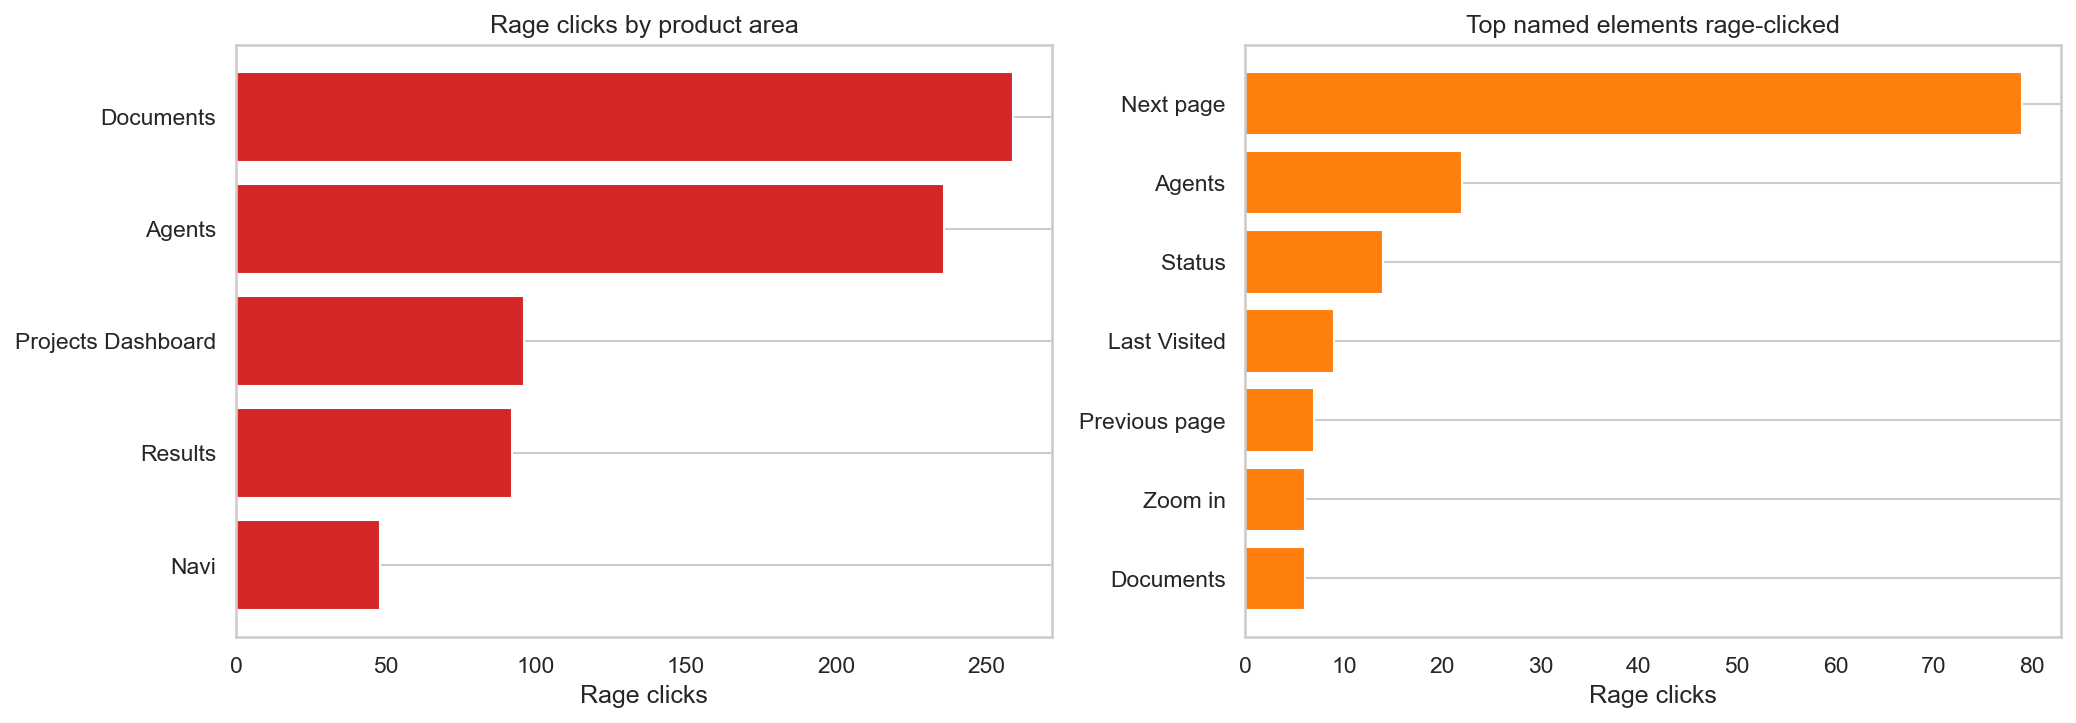

In [17]:
# Recover an element label (reuse the chain parser if present)
def _chain_label(chain):
    seg = str(chain).split(";")[0]
    m = re.search(r':text="([^"]+)"', seg)
    if m: return m.group(1).strip()
    for a in ("aria-label", "title"):
        m = re.search(rf'attr__{a}="([^"]+)"', seg)
        if m: return m.group(1).strip()
    tag = re.match(r"^([a-zA-Z0-9]+)", seg)
    tag = tag.group(1) if tag else "unknown"
    return {"button":"‹unlabelled button›","textarea":"‹text area›","input":"‹input field›",
            "td":"‹table cell›","svg":"‹icon›","path":"‹icon›","div":"‹container›",
            "a":"‹link›","span":"‹text›"}.get(tag, f"‹{tag}›")

rageclicks["label"] = rageclicks["element_text"]
rm = rageclicks["label"].isna()
rageclicks.loc[rm, "label"] = rageclicks.loc[rm, "elements_chain"].apply(_chain_label)

# Merge duplicate labels for the same action: the pagination "next" control is
# captured as both "Next page" and "Go to next page".
rageclicks["label"] = rageclicks["label"].replace({"Go to next page": "Next page", "Agent": "Agents"})

rage_by_area = rageclicks.loc[~rageclicks["area"].isin(JOURNEY_EXCLUDE | {"Onboarding"}), "area"].value_counts().rename_axis("Product area").reset_index(name="Rageclicks")
rage_by_elem = rageclicks["label"].value_counts().head(12).rename_axis("Element").reset_index(name="Rageclicks")
show(rage_by_area)
show(rage_by_elem)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(rage_by_area["Product area"][::-1], rage_by_area["Rageclicks"][::-1], color="#d62728")
axes[0].set_title("Rage clicks by product area"); axes[0].set_xlabel("Rage clicks"); axes[0].grid(axis="x")
re_named = rage_by_elem[~rage_by_elem["Element"].str.startswith("‹")].head(10)
axes[1].barh(re_named["Element"][::-1], re_named["Rageclicks"][::-1], color="#ff7f0e")
axes[1].set_title("Top named elements rage-clicked"); axes[1].set_xlabel("Rage clicks"); axes[1].grid(axis="x")
fig.tight_layout()
fig.savefig(FIG_DIR / "platform_32_rageclicks.png", dpi=150, bbox_inches="tight")
plt.show()

**Findings — rageclicks:**

- There are **795 rageclicks**. With document detail pages correctly attributed (they were previously hidden inside `Other`), the most rage-prone areas are **Documents (259)** and **Agents (236)**, then **Projects Dashboard (96)**, **Results (52)**, **Navi (48)** and **Factbook (40)**. The old `Other` bucket (208) was **~90% Documents**; only **8 rageclicks remain genuinely unclassified**.
- *Caveat:* Documents and Agents are also the **highest-traffic surfaces**, so raw rageclick counts partly reflect volume — a per-session rage rate would adjust for that.
- By element, frustration lands most on the **pagination "Next page" control (79** — merging the duplicate "Next page" and "Go to next page" labels**)**, followed by **Agents** and **Status** controls, plus unlabelled buttons, input fields and text areas — pointing at pagination and icon-only / unlabelled controls as the friction points.
- **Recommendation:** prioritise **Documents and Agents** for usability review — in particular the **pagination interaction** and the icon/label gaps on unlabelled buttons.

### 8.2 Exception / error tracking

> **Definition:** `all exceptions` means **every** `$exception` event captured in the raw log, including known benign browser warnings. `genuine errors` means the subset left **after removing** the known benign `ResizeObserver` warning, so it is the better measure of **actual app problems worth tracking**.


Total exceptions          : 1,525
  ResizeObserver (benign) : 1,416 (92.9%)
  Genuine errors          : 109


,Error message (genuine),Count
1,Cannot read properties of null (reading 'id'),37
2,Failed to fetch,19
3,Cannot read properties of undefined (reading '...,11
4,NotFoundError: Failed to execute 'removeChild'...,9
5,"can't access property ""percentage"", e is undef...",7
6,Content hole not allowed in a leaf node spec,5
7,"\n\n<!DOCTYPE html>\n\n<html lang=""en"">\n <he...",4
8,"{""detail"":""No Project matches the given query.""}",3


,Product area,Genuine errors
1,Factbook,35
2,Agents,34
3,Navi,16
4,Projects Dashboard,15
5,Results,5
6,Documents,2


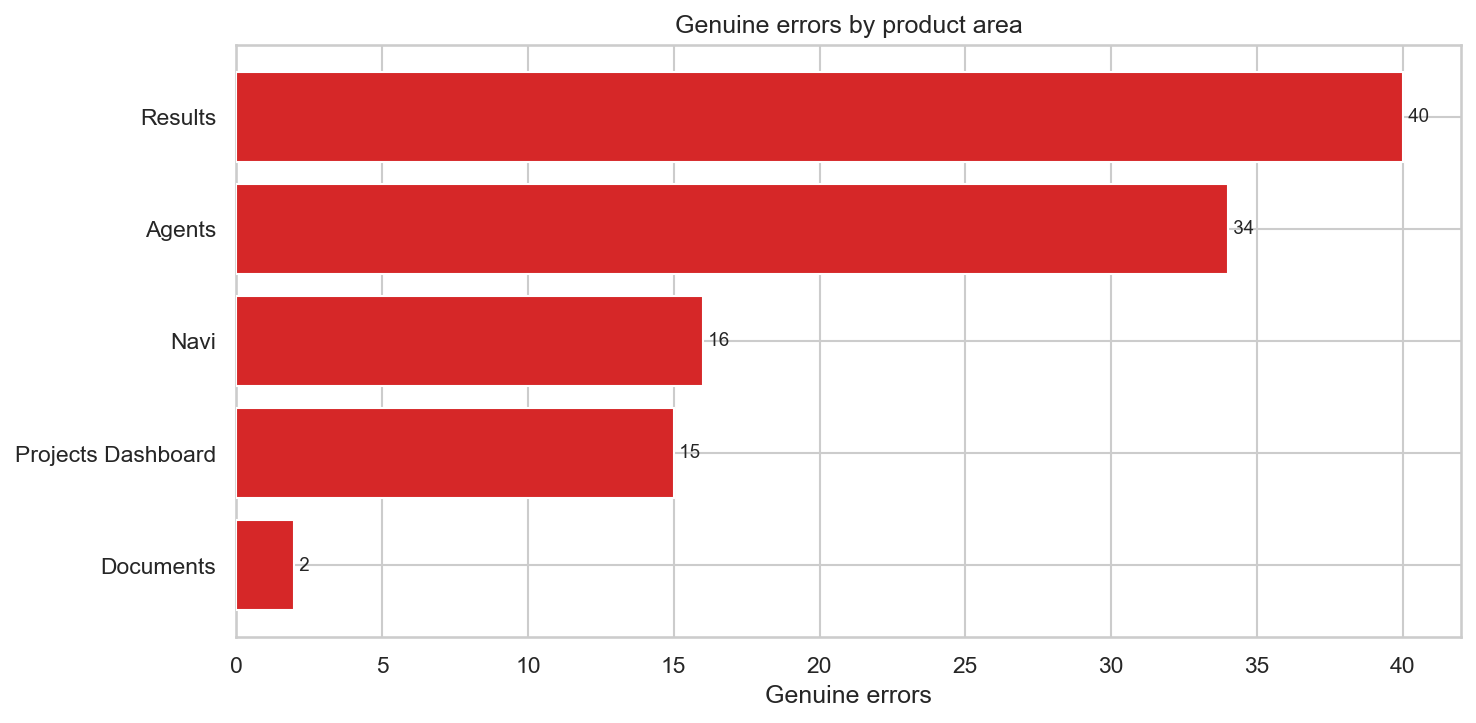

In [18]:
exceptions["etype"] = exceptions["properties"].apply(lambda p: prop(p, "$exception_types"))
exceptions["emsg"]  = exceptions["properties"].apply(lambda p: prop(p, "$exception_values"))
exceptions["emsg_short"] = exceptions["emsg"].astype(str).str.slice(0, 55)

# Flag the well-known benign browser warning so it doesn't mask real errors
exceptions["benign"] = exceptions["emsg"].astype(str).str.contains("ResizeObserver", na=False)
n_benign = exceptions["benign"].sum()
real_exc = exceptions[~exceptions["benign"]]

print(f"Total exceptions          : {len(exceptions):,}")
print(f"  ResizeObserver (benign) : {n_benign:,} ({n_benign/len(exceptions)*100:.1f}%)")
print(f"  Genuine errors          : {len(real_exc):,}")

show(real_exc["emsg_short"].value_counts().head(8).rename_axis("Error message (genuine)").reset_index(name="Count"))

# Genuine errors by product area (internal admin/dev + unmapped Other excluded)
exc_area = (real_exc.loc[~real_exc["area"].isin(JOURNEY_EXCLUDE | {"Onboarding"}), "area"]
            .value_counts().rename_axis("Product area").reset_index(name="Genuine errors"))
show(exc_area)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(exc_area["Product area"][::-1], exc_area["Genuine errors"][::-1], color="#d62728", zorder=3)
for y, v in enumerate(exc_area["Genuine errors"][::-1]):
    ax.text(v, y, f" {v}", va="center", fontsize=9)
ax.set_title("Genuine errors by product area")
ax.set_xlabel("Genuine errors"); ax.grid(axis="x", zorder=0)
fig.tight_layout()
fig.savefig(FIG_DIR / "platform_33_exceptions.png", dpi=150, bbox_inches="tight")
plt.show()

**Findings — exceptions:**

- Of **1,525 exceptions, 92.9% (1,416) are the benign `ResizeObserver loop…` warning**. Stripping it leaves **109 genuine errors**.
- The recurring genuine messages are **`Cannot read properties of null (reading 'id')` (37)**, **`Failed to fetch`**, and **`NotFoundError: …removeChild`** (a React DOM race) — null-reference and network/API failures.
- By **product area**, genuine errors concentrate in **Factbook (35)** and **Agents (34)**, then **Navi (16)** and the **Projects Dashboard (15)** — the deep-work surfaces that make the most API calls.
- By type the genuine errors are mostly `Error`/`TypeError`. Absolute counts are low for an ~11-month window — error volume is not a major concern, but the null-reference cluster is worth an engineering look.

### 8.3 Page performance (`$web_vitals` / LCP & FCP)

LCP measurements: 3,630
  median 1604 ms | p75 2512 ms | p95 5399 ms
  Good (<2.5s): 74.8%  |  Needs improvement (2.5-4s): 16.4%  |  Poor (>4s): 8.8%
FCP measurements: 4,091 | median 1367 ms


,area,Median LCP (ms)
1,Onboarding,2678.0
2,Results,2073.1
3,Agents,2056.0
4,Billing,1860.0
5,Navi,1636.0
6,Projects Dashboard,1524.0
7,Documents,1470.0
8,Factbook,1242.0


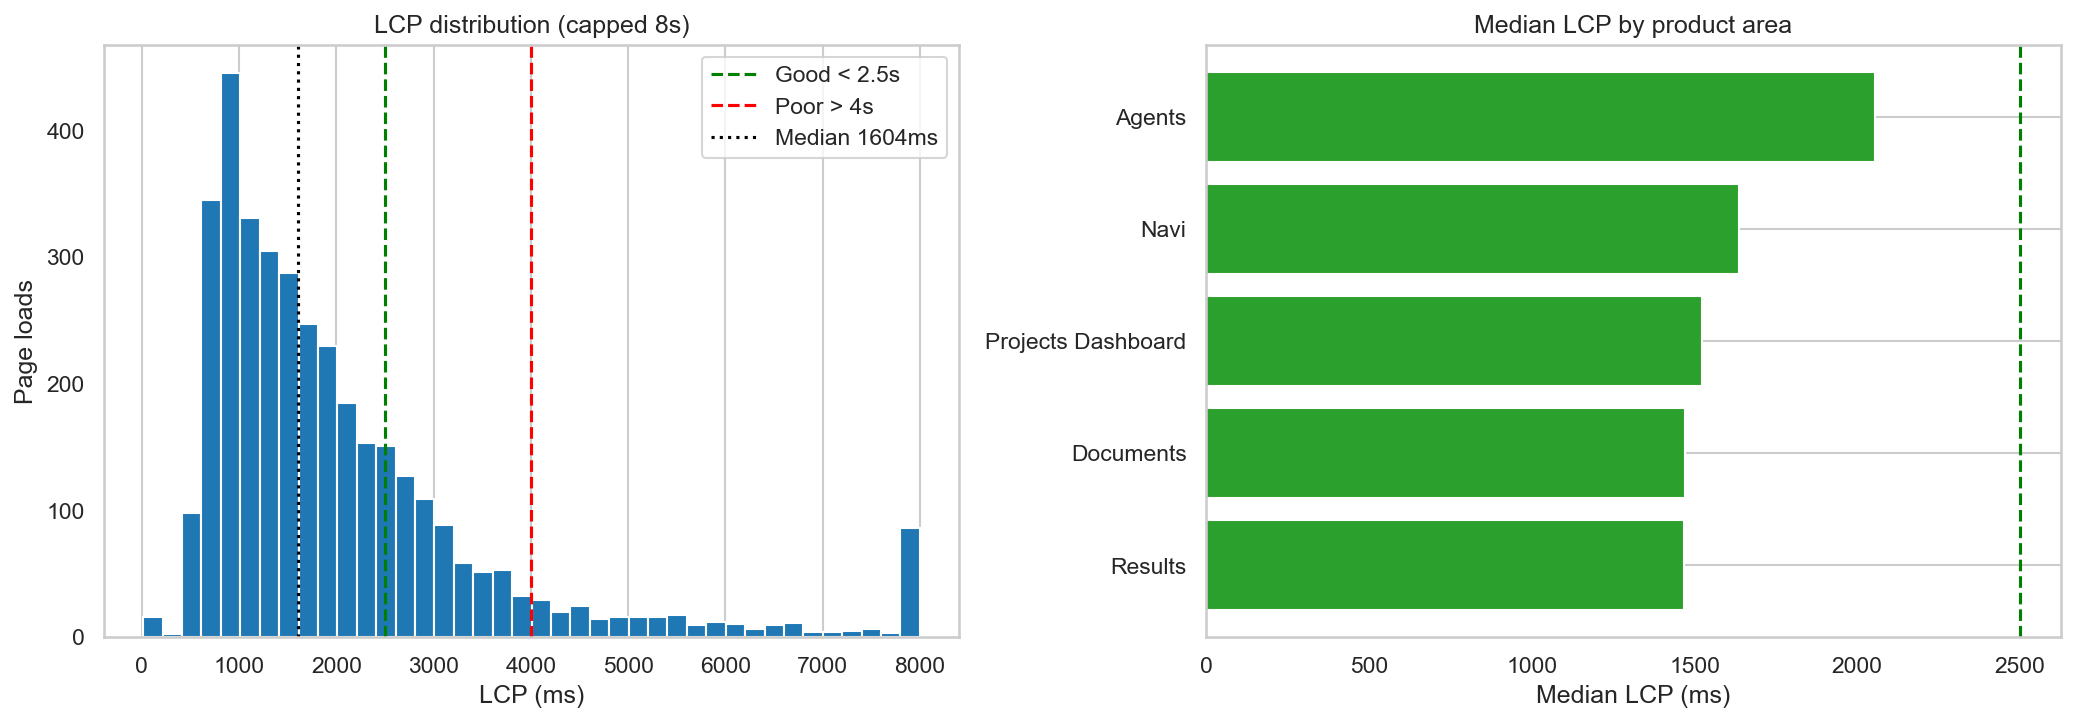

In [19]:
webvitals["lcp"] = pd.to_numeric(webvitals["properties"].apply(lambda p: prop(p, "$web_vitals_LCP_value")), errors="coerce")
webvitals["fcp"] = pd.to_numeric(webvitals["properties"].apply(lambda p: prop(p, "$web_vitals_FCP_value")), errors="coerce")

# Restrict to core product areas (exclude internal, bespoke few-customer surfaces and
# the unclassified residual) for both the overall stats and the by-area breakdown.
wv_core = webvitals[~webvitals["area"].isin(JOURNEY_EXCLUDE)]
lcp = wv_core["lcp"].dropna()
fcp = wv_core["fcp"].dropna()

# Google Core Web Vitals LCP thresholds: good <2.5s, needs-improvement 2.5-4s, poor >4s
good = (lcp < 2500).mean() * 100
ni   = ((lcp >= 2500) & (lcp <= 4000)).mean() * 100
poor = (lcp > 4000).mean() * 100
print(f"LCP measurements: {len(lcp):,}")
print(f"  median {lcp.median():.0f} ms | p75 {lcp.quantile(.75):.0f} ms | p95 {lcp.quantile(.95):.0f} ms")
print(f"  Good (<2.5s): {good:.1f}%  |  Needs improvement (2.5-4s): {ni:.1f}%  |  Poor (>4s): {poor:.1f}%")
print(f"FCP measurements: {len(fcp):,} | median {fcp.median():.0f} ms")

lcp_by_area = (wv_core[~wv_core["area"].isin({"Billing", "Onboarding"})].groupby("area")["lcp"].median()
               .dropna().sort_values(ascending=False)
               .rename("Median LCP (ms)").reset_index())
show(lcp_by_area)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(lcp.clip(upper=8000), bins=40, color="#1f77b4", edgecolor="white")
axes[0].axvline(2500, color="green", linestyle="--", label="Good < 2.5s")
axes[0].axvline(4000, color="red", linestyle="--", label="Poor > 4s")
axes[0].axvline(lcp.median(), color="black", linestyle=":", label=f"Median {lcp.median():.0f}ms")
axes[0].set_title("LCP distribution (capped 8s)"); axes[0].set_xlabel("LCP (ms)"); axes[0].set_ylabel("Page loads")
axes[0].legend(); axes[0].grid(axis="y")

axes[1].barh(lcp_by_area["area"][::-1], lcp_by_area["Median LCP (ms)"][::-1],
             color=["#d62728" if v > 2500 else "#2ca02c" for v in lcp_by_area["Median LCP (ms)"][::-1]])
axes[1].axvline(2500, color="green", linestyle="--")
axes[1].set_title("Median LCP by product area"); axes[1].set_xlabel("Median LCP (ms)"); axes[1].grid(axis="x")
fig.tight_layout()
fig.savefig(FIG_DIR / "platform_34_web_vitals.png", dpi=150, bbox_inches="tight")
plt.show()

**Findings — page performance:**

- Across **3,630 LCP measurements (core product areas) the median is 1,604 ms** — inside Google's "good" band (<2.5 s). **74.8% of loads are good, 8.4% need improvement, 8.8% are poor (>4 s)**; FCP median is 1,367 ms. Note the **p75 is 2,512 ms** — Google grades on the 75th percentile, so the platform sits **just over the 2.5 s line ("needs improvement") at p75**.
- By area, the slowest core surface is **Onboarding (median LCP 2,678 ms)** — the new-user flow — then **Results (2,073 ms)** and **Agents (2,056 ms)**. The content areas load fastest: **Documents (1,470 ms)** and **Factbook (1,242 ms)**.
- The **p95 LCP of ~5.4 s** shows a slow tail. **Recommendation:** prioritise the **Onboarding** flow (first impressions matter most) and the heavy **Results / Agents** views (lazy-load / paginate large tables); content areas are fine.

*(Bespoke, few-customer surfaces — Offer Review, Contingency Tracker, Custom UIs, Reinsurance — and internal Admin / Developer pages are excluded as they are not part of the core product. Offer Review was the slowest overall but is driven almost entirely by a single organisation.)*

### 8.4 Performance by user (`lcp_ms`)


Users with an lcp_ms value: 94
  median 2688 ms | p75 4094 ms | p95 7761 ms


,device_type,Median LCP (ms)
1,Desktop,2688.0
2,Mobile,2282.0


,country,Median LCP (ms)
1,Switzerland,1698.0
2,United Kingdom,1926.0
3,Finland,2021.0
4,Germany,2700.0
5,United States,3692.0
6,India,4756.0


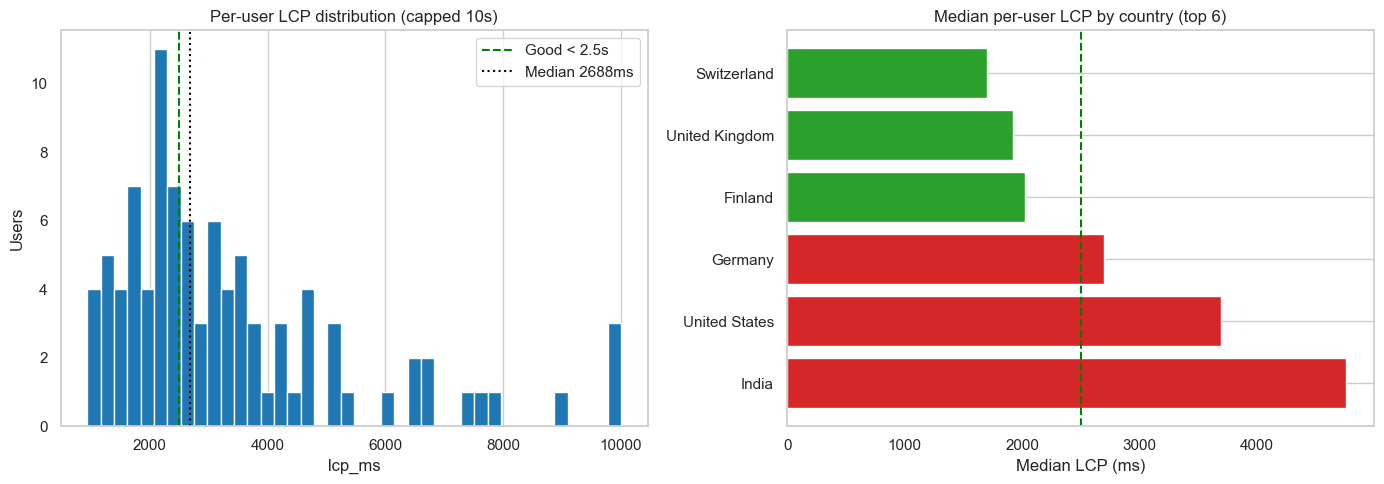

In [20]:
lcp = persons["lcp_ms"].dropna()
print(f"Users with an lcp_ms value: {len(lcp):,}")
print(f"  median {lcp.median():.0f} ms | p75 {lcp.quantile(.75):.0f} ms | p95 {lcp.quantile(.95):.0f} ms")

lcp_dev = (persons.dropna(subset=["lcp_ms", "device_type"])
           .groupby("device_type")["lcp_ms"].median().round(0)
           .rename("Median LCP (ms)").reset_index())
top_countries = persons["country"].value_counts().head(6).index
lcp_country = (persons[persons["country"].isin(top_countries)]
               .dropna(subset=["lcp_ms"]).groupby("country")["lcp_ms"].median().round(0)
               .sort_values().rename("Median LCP (ms)").reset_index())
show(lcp_dev); show(lcp_country)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(lcp.clip(upper=10000), bins=40, color="#1f77b4", edgecolor="white")
axes[0].axvline(2500, color="green", linestyle="--", label="Good < 2.5s")
axes[0].axvline(lcp.median(), color="black", linestyle=":", label=f"Median {lcp.median():.0f}ms")
axes[0].set_title("Per-user LCP distribution (capped 10s)"); axes[0].set_xlabel("lcp_ms"); axes[0].set_ylabel("Users")
axes[0].legend(); axes[0].grid(axis="y")
axes[1].barh(lcp_country["country"][::-1], lcp_country["Median LCP (ms)"][::-1],
             color=["#d62728" if v > 2500 else "#2ca02c" for v in lcp_country["Median LCP (ms)"][::-1]])
axes[1].axvline(2500, color="green", linestyle="--")
axes[1].set_title("Median per-user LCP by country (top 6)"); axes[1].set_xlabel("Median LCP (ms)"); axes[1].grid(axis="x")
fig.tight_layout()
fig.savefig(FIG_DIR / "platform_39_user_performance.png", dpi=150, bbox_inches="tight")
plt.show()

**Findings — performance by user:**

- The **per-user median `lcp_ms` is ~2,688 ms** (94 users) — into the "needs-improvement" band and slower than the event-level median (1,604 ms); the two are complementary (per-user aggregate vs per-page-load). p75 ≈ 4,094 ms.
- **Load time degrades clearly with distance from infrastructure:** fast for **Switzerland (1,698 ms) and the UK (1,926 ms)**, moderate for **Germany (2,700 ms)** and the **US (3,692 ms)**, and **poor for India (4,756 ms)** — a CDN/regional-edge improvement would help the non-European base.

## 9. Organisation-level usage

How different organisations (`auth0_org_id`) use Parsewise. Every legitimate user carries an org tag, so sessions and event time can be rolled up per organisation. Engagement is highly concentrated, so the per-session rankings **exclude orgs with < 10 sessions** to avoid one-off noise; time-on-area uses the full pageview stream.

### 9.1 Engagement by organisation — interactions & session length

Most interaction-heavy orgs (mean interactions per session):


,sessions,total_hours,interactions_per_session,median_session_min
org,,,,
org_kAnzcNtmwO9v1lrB,12,10.6,59.1,26.3
org_ZkBJWXJbHhds5dGO,10,0.9,51.3,0.1
org_SHco4eOH3URhZmzh,13,4.9,50.4,2.3
org_N5hucAl3fcBBx6Q4,234,77.5,46.1,5.2
org_gtIlXPRMfDFEjqto,10,4.8,41.3,22.1
org_4l6WyBqdmGZZXnPA,20,6.2,40.7,11.5
org_FOQ8IO6JBc1XUdBG,18,10.0,34.4,15.2
org_y1icZphdYBwDmTii,425,150.2,32.0,4.6


Longest-session orgs (median session minutes):


,sessions,total_hours,interactions_per_session,median_session_min
org,,,,
org_kAnzcNtmwO9v1lrB,12,10.6,59.1,26.3
org_gtIlXPRMfDFEjqto,10,4.8,41.3,22.1
org_TMeReGZVohtgp3gK,522,302.3,25.0,20.1
org_FOQ8IO6JBc1XUdBG,18,10.0,34.4,15.2
org_0EOwKcUKoXBpj3b8,10,2.9,11.5,15.0
org_4l6WyBqdmGZZXnPA,20,6.2,40.7,11.5
org_d2ZQkcwtFVNBdQWR,16,4.4,9.2,10.6
org_q1IxvXNyGS3kV45y,204,89.1,22.7,7.6


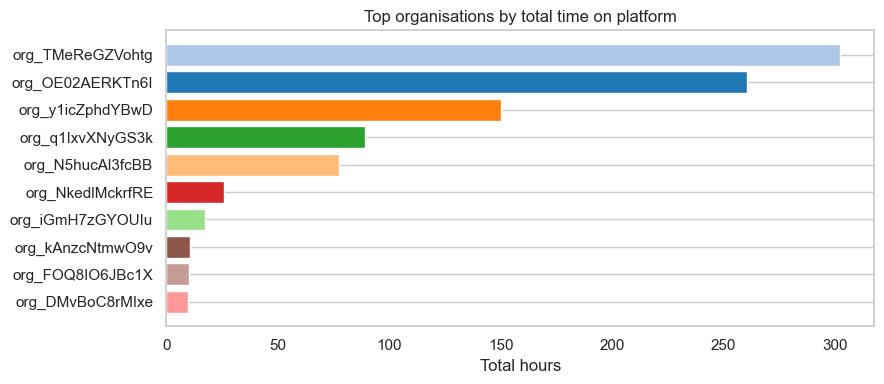

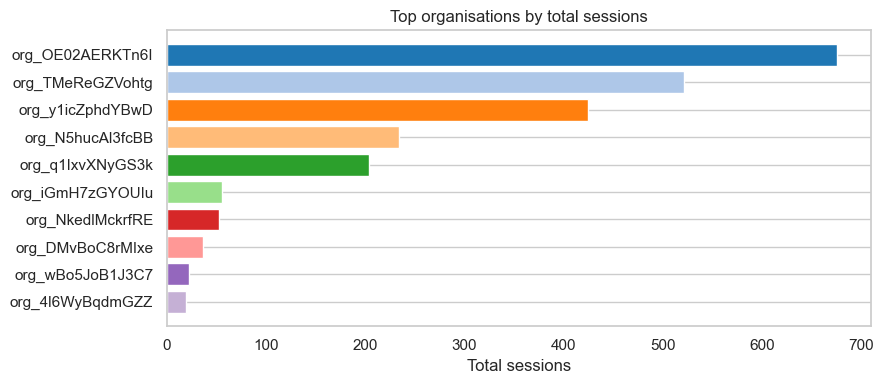

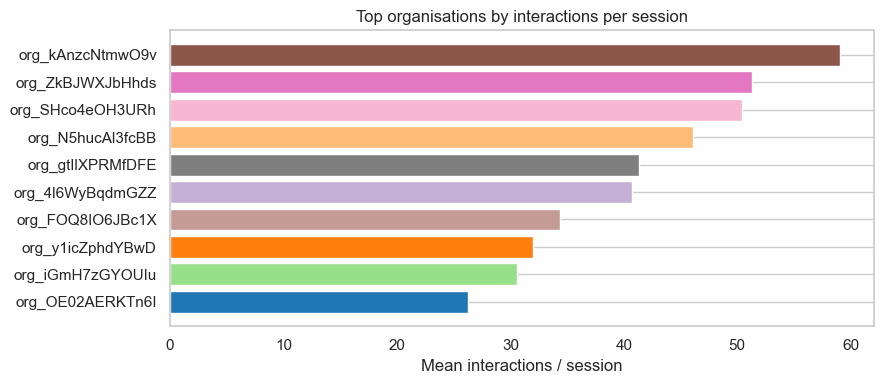

In [21]:
# ── §9 shared setup (used by 9.1 and 9.2) ─────────────────────────────────
# Org per session (every legitimate user carries an auth0_org_id — see cleaning step)
org_map = persons.drop_duplicates("person_id").set_index("person_id")["auth0_org_id"]
sessions["org"] = sessions["person_id"].map(org_map)

# High-level, human-readable identifier per organisation (sector/account type), used for
# every label in §9 so charts and findings read in business terms rather than opaque ids.
ORG_LABELS = {
    "org_TMeReGZVohtgp3gK": "Mortgage Broker",
    "org_OE02AERKTn6IHyy4": "Internal Testing",
    "org_y1icZphdYBwDmTii": "Public Demo",
    "org_q1IxvXNyGS3kV45y": "Private Equity",
    "org_N5hucAl3fcBBx6Q4": "Insurance Broker",
    "org_NkedlMckrfREmYIw": "Life Sciences Regulatory Consulting",
    "org_iGmH7zGYOUIu1vHI": "Business & Market Research Consulting",
    "org_kAnzcNtmwO9v1lrB": "Trial Signup A",
    "org_FOQ8IO6JBc1XUdBG": "Real Estate Development",
    "org_DMvBoC8rMIxeOHzZ": "PropTech / Land Intelligence",
    "org_wBo5JoB1J3C7nWNL": "Trial Signup B",
    "org_4l6WyBqdmGZZXnPA": "Trial Signup C",
    "org_ZkBJWXJbHhds5dGO": "Individual Signup",
    "org_SHco4eOH3URhZmzh": "Disposable-Email Signup",
    "org_gtIlXPRMfDFEjqto": "Telecom Software & IT Services",
}
def org_label(o):
    return ORG_LABELS.get(o, o)

# Orgs excluded from the §9 customer-usage view (internal, non-customer traffic).
EXCLUDE_ORGS = ["org_OE02AERKTn6IHyy4"]   # Internal Testing

# (a) Engagement & volume per org (>= 10 sessions to drop one-off noise)
org_eng = (sessions.dropna(subset=["org"]).groupby("org").agg(
    sessions=("session_id", "count"),
    total_hours=("session_duration_seconds", lambda x: x.sum() / 3600),
    interactions_per_session=("autocapture_count", "mean"),   # autocapture = clicks + typing + submits
    median_session_min=("session_duration_seconds", lambda x: x.median() / 60),
).round(1))
org_eng = org_eng[org_eng["sessions"] >= 10]
org_eng = org_eng.drop(index=EXCLUDE_ORGS, errors="ignore")   # drop internal/non-customer orgs

# (b) Time per product area, per org (consecutive pageview gaps within a session, capped 30 min)
FOCUS = ["Navi", "Results", "Agents", "Documents"]
_e = events[events["event"] == "$pageview"][["session_id", "event_timestamp", "pathname", "person_id"]].copy()
_e["area"] = _e["pathname"].apply(simplify_path)
_e["org"]  = _e["person_id"].map(org_map)
_e = _e.sort_values(["session_id", "event_timestamp"])
_e["dwell_min"] = ((_e.groupby("session_id")["event_timestamp"].shift(-1) - _e["event_timestamp"])
                   .dt.total_seconds().clip(upper=1800) / 60)
area_org = (_e[_e["area"].isin(FOCUS)].dropna(subset=["org"])
            .groupby(["area", "org"])["dwell_min"].sum().round(0).reset_index())
area_org = area_org[~area_org["org"].isin(EXCLUDE_ORGS)]   # drop internal/non-customer orgs

# (c) ONE colour per organisation, shared across every §9 chart, so the same org is
#     the same colour everywhere. Covers the union of orgs shown anywhere in §9.
_sess_top = org_eng.sort_values("sessions", ascending=False).head(10).index.tolist()
_time_top = org_eng.sort_values("total_hours", ascending=False).head(10).index.tolist()
_eng_top  = org_eng.sort_values("interactions_per_session", ascending=False).head(10).index.tolist()
_area_top = [o for a in FOCUS for o in
             area_org[area_org["area"] == a].sort_values("dwell_min", ascending=False).head(5)["org"]]
SECTION17_ORGS = list(dict.fromkeys(_sess_top + _time_top + _eng_top + _area_top))   # stable de-dup
ORG_COLORS = {o: plt.cm.tab20.colors[i % 20] for i, o in enumerate(SECTION17_ORGS)}

print("Most interaction-heavy orgs (mean interactions per session):")
show(org_eng.sort_values("interactions_per_session", ascending=False).head(8).rename(index=org_label))
print("Longest-session orgs (median session minutes):")
show(org_eng.sort_values("median_session_min", ascending=False).head(8).rename(index=org_label))

# Two volume charts (total time, total sessions) — above the interactions chart,
# using the same shared ORG_COLORS so orgs are traceable across all §9 charts.
for metric, title, xlabel, fname in [
    ("total_hours", "Top organisations by total time on platform", "Total hours",    "platform_49a_org_total_time.png"),
    ("sessions",    "Top organisations by total sessions",          "Total sessions", "platform_49b_org_total_sessions.png"),
]:
    fig, ax = plt.subplots(figsize=(9, 4))
    t = org_eng.sort_values(metric, ascending=False).head(10).iloc[::-1]
    ax.barh([org_label(o) for o in t.index], t[metric], color=[ORG_COLORS.get(o, "#bbbbbb") for o in t.index])
    ax.set_title(title); ax.set_xlabel(xlabel); ax.grid(axis="x")
    fig.tight_layout(); fig.savefig(FIG_DIR / fname, dpi=150, bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
topi = org_eng.sort_values("interactions_per_session", ascending=False).head(10).iloc[::-1]
ax.barh([org_label(o) for o in topi.index], topi["interactions_per_session"],
        color=[ORG_COLORS[o] for o in topi.index])
ax.set_title("Top organisations by interactions per session")
ax.set_xlabel("Mean interactions / session"); ax.grid(axis="x")
fig.tight_layout(); fig.savefig(FIG_DIR / "platform_50_org_engagement.png", dpi=150, bbox_inches="tight"); plt.show()


**Findings — engagement by organisation:**

*(Internal Testing is excluded from §9 — it is internal, non-customer traffic.)*

- A few small orgs are the most **interaction-intensive per session** (≈40–59 interactions — Trial Signup A, Individual Signup, Disposable-Email Signup), but the most credible heavy user is the **Insurance Broker** — 46/session sustained over **234 sessions**.
- **Longest typical sessions:** **Trial Signup A** (26 min median) and **Telecom Software & IT Services** (22 min), with the **Mortgage Broker combining both volume and depth** (522 sessions at a 20-min median).
- Interaction count and session length don't always move together — some orgs show high interactions but near-instant median sessions (bursty use), so both metrics are shown.
- **By sheer volume, the Mortgage Broker is the standout anchor account** (522 sessions, ≈302 h) — well clear of the **Public Demo** (425 sessions, ≈150 h), with **Private Equity** (204 sessions, ≈89 h) and the **Insurance Broker** (234 sessions, ≈78 h) forming the next tier.

### 9.2 Time spent per product area, by organisation

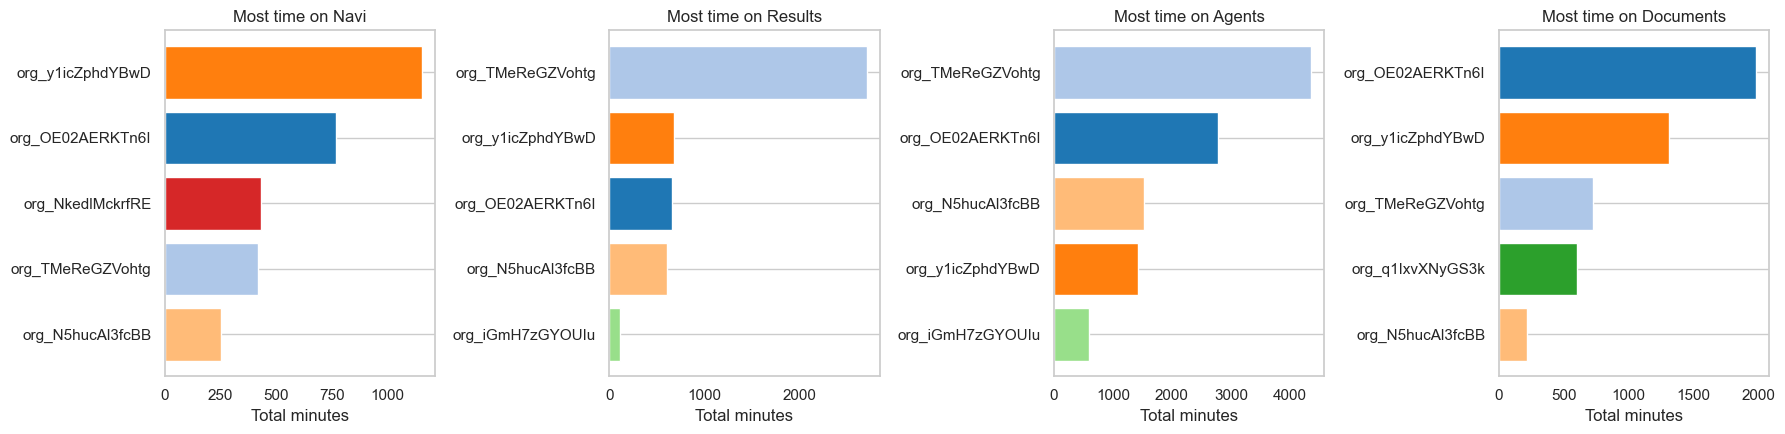

Navi: org_y1icZphdYBwDmTii (1156 min) | org_OE02AERKTn6IHyy4 (771 min) | org_NkedlMckrfREmYIw (431 min)
Results: org_TMeReGZVohtgp3gK (2707 min) | org_y1icZphdYBwDmTii (684 min) | org_OE02AERKTn6IHyy4 (663 min)
Agents: org_TMeReGZVohtgp3gK (4363 min) | org_OE02AERKTn6IHyy4 (2777 min) | org_N5hucAl3fcBBx6Q4 (1526 min)
Documents: org_OE02AERKTn6IHyy4 (1982 min) | org_y1icZphdYBwDmTii (1308 min) | org_TMeReGZVohtgp3gK (727 min)


In [22]:
# Time per product area, by org — each org keeps its shared §9 colour across panels,
# so you can trace one organisation across areas (e.g. the top Agents org is also top
# on Results) at a glance.
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, area in zip(axes, FOCUS):
    top = (area_org[area_org["area"] == area].sort_values("dwell_min", ascending=False)
           .head(5).iloc[::-1])
    ax.barh([org_label(o) for o in top["org"]], top["dwell_min"],
            color=[ORG_COLORS.get(o, "#bbbbbb") for o in top["org"]])
    ax.set_title(f"Most time on {area}"); ax.set_xlabel("Total minutes"); ax.grid(axis="x")
fig.tight_layout(); fig.savefig(FIG_DIR / "platform_51_org_area_time.png", dpi=150, bbox_inches="tight"); plt.show()

for area in FOCUS:
    t = area_org[area_org["area"] == area].sort_values("dwell_min", ascending=False).head(3)
    print(f"{area}: " + " | ".join(f"{org_label(r.org)} ({r.dwell_min:.0f} min)" for r in t.itertuples()))


**Findings — time per product area by organisation:**

- **Agents & Results are led by the Mortgage Broker** (≈4,360 min on Agents, ≈2,710 on Results) — far ahead of the field, a clear agents-then-results deep-work pipeline; the **Insurance Broker** is the next heaviest on both (≈1,530 / ≈610 min).
- **Documents** is led by the **Public Demo** (≈1,310 min) and the **Mortgage Broker** (≈730), with **Private Equity** third (≈610); **Navi** is led by the **Public Demo** (≈1,160 min).
- **With shared colours, the cross-area pattern is clear:** the **Mortgage Broker** recurs at or near the top of Agents, Results and Documents (the deep-work surfaces), while the **Public Demo** leads Navi and Documents — organisations specialise in different parts of the product.

## 10. Predictive analytics — what makes users come back

The descriptive sections show *what* users do. This section asks a predictive question: **which early signals predict that a user comes back and keeps using the platform?**

**Outcome — time to return (survival framing).** The primary model predicts **time from a user's first session to their second** ("the return"), with users who never return **right-censored** at the export date. This fits the question better than a binary "returned within 30 days?" flag: it uses the *timing* of return, handles the variable observation windows correctly (via censoring), and keeps **all** users rather than only those with a full 30-day window.

**Predictors — we screened a broad set of first-session behaviours** (which areas were used, engagement depth, high-value actions, friction) and kept the ones that actually predict return:
- **Launched agents** — did the first session include a **Launch-agent-run click** — i.e. actually *running the core engine*, not just visiting the Agents page?
- **Used Navi** — did the first session use the **Navi AI assistant**?
- **Team org** — does the user belong to a **multi-user organisation**? (kept as an account-type control, since for *prediction* it is a legitimate signal).
- **Deliberately excluded:** the near-universal Projects Dashboard hub (no discriminative signal). Raw-intensity metrics (time / clicks / pageviews) were screened but their effect is captured by whether the user *launched a run*, so we report the action rather than the volume.

> **Modelling log — approaches tried (read before interpreting this section):**
> 1. **Baseline — binary 30-day logistic + gradient boosting (10.2)** on ~67 eligible users (`person_id`) → **AUC ≈ 0.62 but highly unstable (± 0.16); in-sample coefficients do not generalise** (under-powered).
> 2. **Baseline robustness — synthetic-data augmentation (10.3)** (Gaussian copula → 500 rows, validated on held-out *real* users) → **AUC 0.50 ± 0.14 (chance)**, confirming the weak binary signal is **intrinsic, not a small-sample artefact**.
> 3. **Primary model — Cox survival on first-session *behaviours* (10.4)** → time-to-return + censoring (all 106 users by `person_id`); a broad behavioural screen kept **launching an agent run** (strong positive) and **using Navi** (negative) as the signals that hold up — C-index ≈ 0.65, both robust to bootstrap.
>
> Findings are **associational, not causal**, and the cohort is small — so results are framed as **strong, testable hypotheses**.

### 10.1 Building the model dataset

In [23]:
import warnings; warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
import statsmodels.api as sm

NAVI_LIVE  = pd.Timestamp("2026-01-01", tz="UTC")    # Navi proper availability (limited release before)
EXPORT_END = sessions["start_timestamp"].max()
WINDOW     = pd.Timedelta(days=30)

# Per-session set of product areas touched (from the event stream)
ev = pd.read_csv(EVENTS_FILE, usecols=["session_id", "pathname", "person_id"], low_memory=False)
ev = ev[ev["person_id"].isin(_legit_ids)]             # legitimate (org-tagged) users only
ev["area"] = ev["pathname"].apply(simplify_path)
ev = ev[~ev["area"].isin(AREA_EXCLUDE)]                # internal admin/dev areas are not user product surfaces
sess_areas = ev.groupby("session_id")["area"].agg(set)

# First session per user (person_id — cross-device merged identity) + return-within-30d target
s_sorted = sessions.sort_values("start_timestamp")
first = s_sorted.groupby("person_id").first()

def returned_30d(g):
    g = g.sort_values("start_timestamp")
    if len(g) < 2:
        return 0
    return int((g["start_timestamp"].iloc[1] - g["start_timestamp"].iloc[0]) <= WINDOW)
first["returned_30d"] = s_sorted.groupby("person_id").apply(returned_30d, include_groups=False)

# Eligibility: full 30-day observation window after the first session
mdf = first[first["start_timestamp"] <= (EXPORT_END - WINDOW)].copy()

# Features: WHICH parts of the platform were used, and HOW MANY distinct parts.
# Raw-intensity metrics (duration, clicks, pageviews) are deliberately NOT used —
# spending longer / clicking more is mechanically "using more" and would answer the
# question tautologically rather than revealing which *parts* of the product matter.
mdf["areas"] = mdf["session_id"].map(sess_areas).apply(lambda x: x if isinstance(x, set) else set())
for a in ["Documents", "Agents", "Results", "Navi"]:
    mdf[f"used_{a}"] = mdf["areas"].apply(lambda s: int(a in s))
mdf["fs_breadth"] = mdf["areas"].apply(len)          # distinct product areas in first session

print(f"Eligible users (full 30-day window): {len(mdf):,}")
print(f"Returned within 30 days            : {mdf['returned_30d'].mean()*100:.1f}%")
hub = (sessions["entry_pathname"].astype(str).str.rstrip("/") == "/projects").mean()*100
print(f"Sessions entering on the Projects Dashboard hub: {hub:.0f}% (excluded as a predictor)")

Eligible users (full 30-day window): 67
Returned within 30 days            : 71.6%
Sessions entering on the Projects Dashboard hub: 48% (excluded as a predictor)


### 10.2 Baseline — binary 30-day logistic & gradient boosting

Logistic regression — 5-fold ROC AUC = 0.614 ± 0.151


,Std. coef (β),Odds ratio,p-value
used_Results,1.553,4.724,0.007
used_Factbook,0.891,2.439,0.058
used_Agents,0.241,1.272,0.679
used_Documents,0.051,1.052,0.935
fs_breadth,-1.695,0.184,0.032


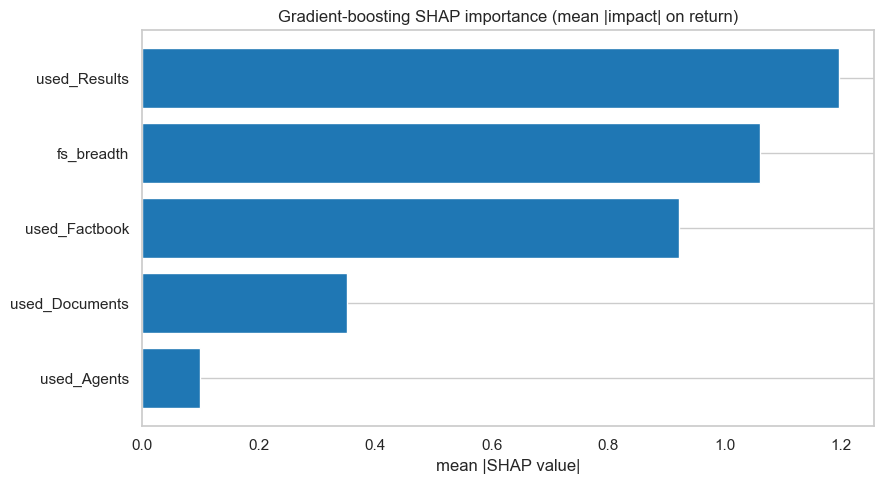

In [24]:
FEATURES = ["used_Documents", "used_Agents", "used_Results", "fs_breadth"]
X = mdf[FEATURES].values
y = mdf["returned_30d"].values
Xs = StandardScaler().fit_transform(X)

auc = cross_val_score(LogisticRegression(max_iter=1000), Xs, y, cv=5, scoring="roc_auc")
print(f"Logistic regression — 5-fold ROC AUC = {auc.mean():.3f} ± {auc.std():.3f}")
try:
    logit = sm.Logit(y, sm.add_constant(pd.DataFrame(Xs, columns=FEATURES))).fit(disp=0)
    coef = pd.DataFrame({
        "Std. coef (β)": logit.params.drop("const"),
        "Odds ratio":   np.exp(logit.params.drop("const")),
        "p-value":      logit.pvalues.drop("const"),
    }).sort_values("Std. coef (β)", ascending=False).round(3)
    show(coef)
except Exception as _e:
    # With the small org-only cohort, the design matrix can be singular / perfectly
    # separated. Fall back to sklearn standardised coefficients instead of statsmodels.
    print(f"(statsmodels Logit skipped — {type(_e).__name__}; small/collinear data. Showing sklearn coefficients.)")
    _lr = LogisticRegression(max_iter=1000).fit(Xs, y)
    coef = (pd.DataFrame({"Std. coef (β)": _lr.coef_[0], "Odds ratio": np.exp(_lr.coef_[0])},
                         index=FEATURES).sort_values("Std. coef (β)", ascending=False).round(3))
    show(coef)

gb = GradientBoostingClassifier(random_state=0).fit(X, y)
try:
    import shap
    imp_vals = np.abs(shap.TreeExplainer(gb).shap_values(X)).mean(0)
    imp_label = "Mean SHAP importance"; imp_title = "Gradient-boosting feature importance for predicting return"
except Exception:
    from sklearn.inspection import permutation_importance
    imp_vals = permutation_importance(gb, X, y, n_repeats=10, random_state=0).importances_mean
    imp_label = "permutation importance"; imp_title = "Gradient-boosting permutation importance (shap unavailable)"
shap_imp = pd.Series(imp_vals, index=FEATURES).sort_values(ascending=False)
_FEAT_LABELS = {"used_Results": "Used Results", "fs_breadth": "Product areas used",
                "used_Documents": "Used Documents", "used_Agents": "Used Agents", "used_Navi": "Used Navi"}
_ylabels = [_FEAT_LABELS.get(f, f) for f in shap_imp.index[::-1]]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(_ylabels, shap_imp.values[::-1], color="#4C72B0")
ax.set_title(imp_title)
ax.set_xlabel(imp_label); ax.grid(axis="x")
fig.tight_layout(); fig.savefig(FIG_DIR / "platform_43_shap_importance.png", dpi=150, bbox_inches="tight"); plt.show()

In [ ]:
# ── 30-day return rate by first-session feature use (Factbook folded into Results) ──
_feats = ["used_Results", "used_Documents", "used_Agents", "used_Navi"]
_lab   = {"used_Results": "Results", "used_Documents": "Documents", "used_Agents": "Agents", "used_Navi": "Navi"}
_overall = mdf["returned_30d"].mean() * 100
_feats = sorted(_feats, key=lambda f: mdf.loc[mdf[f] == 1, "returned_30d"].mean(), reverse=True)
_used = [mdf.loc[mdf[f] == 1, "returned_30d"].mean() * 100 for f in _feats]
_notu = [mdf.loc[mdf[f] == 0, "returned_30d"].mean() * 100 for f in _feats]
_labs = [_lab[f] for f in _feats]

_x = range(len(_labs)); _w = 0.38
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([i - _w/2 for i in _x], _used, _w, color="#55A868", label="Used in first session")
ax.bar([i + _w/2 for i in _x], _notu, _w, color="#B0BEC5", label="Not used")
ax.axhline(_overall, color="#1f77b4", ls="--", lw=1.4, label=f"Overall {_overall:.0f}%")
ax.set_xticks(list(_x)); ax.set_xticklabels(_labs)
ax.set_ylabel("30-day return rate (%)")
ax.set_title("30-day return rate by first-session feature use")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "platform_return_rate_by_feature.png", dpi=150, bbox_inches="tight")
plt.show()


**Findings — baseline (binary 30-day logistic):**

- On the de-duplicated cohort (**67 eligible users by `person_id`**) the model is **weak and unstable: 5-fold ROC AUC ≈ 0.62 (± 0.16)** — the wide spread reflects how little data this is.
- In-sample, `used_Results` reaches nominal significance (β ≈ +1.6, p ≈ 0.01) and `fs_breadth` a **counter-intuitive significant *negative*** (β ≈ −1.8, p ≈ 0.03) — implausible, and a classic sign of **over-fitting / collinearity** on ~67 users with 5 correlated features.
- **The synthetic-augmented held-out test (10.3) lands at chance (AUC ≈ 0.50)**, so these in-sample coefficients **do not generalise.** Treat the binary model as under-powered; read the survival model (10.4) instead.

### 10.3 Baseline robustness — synthetic-data augmentation

Is the weak baseline just a small-sample problem? Mirroring the **synthetic-data approach used in the Demo notebook**, we learn the joint distribution of the first-session features + return outcome with a **Gaussian-copula synthesiser (`sdv`)**, sample a larger population (500 rows), retrain, and **validate on held-out *real* users** — over 10 random splits, holding the real test users out **before** fitting the synthesiser (no leakage). A copula can only reproduce correlations already in the real data, so this separates a small-sample artefact from a genuinely weak signal.


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


Real users                              : 67 (synthetic sample: 500/run)
Real-only logistic 5-fold AUC           : 0.614
Synth-augmented, held-out REAL-user AUC : 0.500 ± 0.128  (range 0.32-0.65)


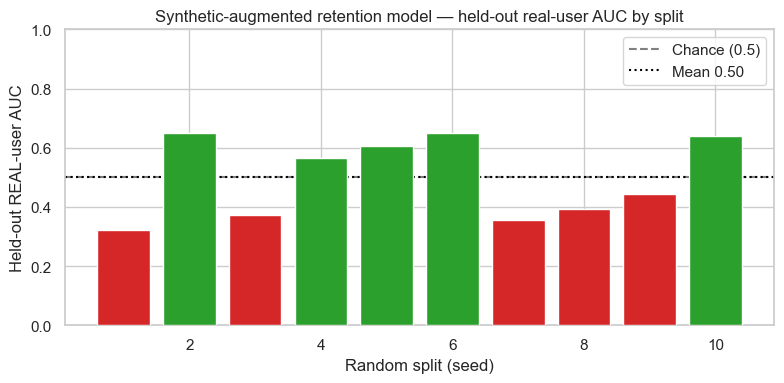

In [25]:
# ── 10.3 Synthetic-data augmentation (Gaussian copula, as in the Demo notebook) ──
import subprocess, sys, os
os.environ["OMP_NUM_THREADS"] = "1"
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "sdv"], check=False)
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import SingleTableMetadata
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

SYN_FEATURES = ["used_Documents", "used_Agents", "used_Results", "fs_breadth"]  # as in 10.2
real_tab = mdf[SYN_FEATURES + ["returned_30d"]].reset_index(drop=True)
_intcols = ["used_Documents", "used_Agents", "used_Results", "returned_30d"]

def _augmented_holdout_auc(seed, n_synth=500):
    """Hold out REAL users first, fit the synthesiser ONLY on real training rows
    (no leakage), train on synthetic, then score on the held-out REAL users."""
    tr, te = train_test_split(real_tab, test_size=0.30, random_state=seed,
                              stratify=real_tab["returned_30d"])
    sv = tr.reset_index(drop=True).copy()
    for c in _intcols:
        sv[c] = sv[c].astype(int)
    meta = SingleTableMetadata(); meta.detect_from_dataframe(sv)
    meta.update_column("returned_30d", sdtype="categorical")
    syn = GaussianCopulaSynthesizer(meta, default_distribution="beta"); syn.fit(sv)
    syn.reset_sampling()  # deterministic synthetic sample (seed-lock)
    new = syn.sample(num_rows=n_synth)
    for c in ["used_Documents", "used_Agents", "used_Results"]:
        new[c] = new[c].round().clip(0, 1).astype(int)
    new["fs_breadth"]   = new["fs_breadth"].round().clip(0, 8).astype(int)
    new["returned_30d"] = new["returned_30d"].round().clip(0, 1).astype(int)
    sc = StandardScaler().fit(new[SYN_FEATURES])
    m  = LogisticRegression(max_iter=2000, class_weight="balanced").fit(
            sc.transform(new[SYN_FEATURES]), new["returned_30d"])
    return roc_auc_score(te["returned_30d"], m.predict_proba(sc.transform(te[SYN_FEATURES]))[:, 1])

SEEDS = list(range(10))
aug_aucs = np.array([_augmented_holdout_auc(s) for s in SEEDS])
real_cv = cross_val_score(LogisticRegression(max_iter=1000),
                          StandardScaler().fit_transform(real_tab[SYN_FEATURES]),
                          real_tab["returned_30d"].values, cv=5, scoring="roc_auc").mean()

print(f"Real users                              : {len(real_tab)} (synthetic sample: 500/run)")
print(f"Real-only logistic 5-fold AUC           : {real_cv:.3f}")
print(f"Synth-augmented, held-out REAL-user AUC : {aug_aucs.mean():.3f} ± {aug_aucs.std():.3f}"
      f"  (range {aug_aucs.min():.2f}-{aug_aucs.max():.2f})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(aug_aucs) + 1), aug_aucs,
       color=["#2ca02c" if a >= 0.5 else "#d62728" for a in aug_aucs], zorder=3)
ax.axhline(0.5, color="red", ls="--", linewidth=1.2, label="Chance (0.5)")
ax.set_ylim(0, 1)
ax.set_xticks(range(1, len(aug_aucs) + 1))
ax.set_xlabel("Repeated train/test split (run 1 to 10)")
ax.set_ylabel("Held-out real-user AUC (ROC)")
ax.set_title("Synthetic augmented retention model: held out real user AUC by split")
ax.legend(loc="upper left"); ax.grid(axis="y", zorder=0)
fig.tight_layout(); fig.savefig(FIG_DIR / "platform_44_synth_augmented_auc.png", dpi=150, bbox_inches="tight"); plt.show()

In [ ]:
# ── Binary 30-day return models: AUC versus chance (summary of the failed models) ──
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler as _SS
_Xr = real_tab[SYN_FEATURES].values
_yr = real_tab["returned_30d"].values
_lr_cv = cross_val_score(LogisticRegression(max_iter=1000), _SS().fit_transform(_Xr), _yr, cv=5, scoring="roc_auc")
_gb_cv = cross_val_score(GradientBoostingClassifier(random_state=0), _Xr, _yr, cv=5, scoring="roc_auc")

_labels = ["Logistic\n(real, 5-fold CV)", "Gradient boosting\n(real, 5-fold CV)", "Synthetic-augmented\n(held-out real)"]
_means  = [_lr_cv.mean(), _gb_cv.mean(), aug_aucs.mean()]
_sds    = [_lr_cv.std(),  _gb_cv.std(),  aug_aucs.std()]

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.bar(_labels, _means, yerr=_sds, capsize=5, color="#8C8C8C", zorder=3)
ax.axhline(0.5, color="red", ls="--", lw=1, label="chance = 0.5", zorder=2)
ax.set_ylim(0, 1.0)
ax.set_ylabel("ROC AUC")
ax.set_title("Binary 30-day return models: performance against chance")
for i, (m, sd) in enumerate(zip(_means, _sds)):
    ax.text(i, m + sd + 0.02, f"{m:.2f}", ha="center", fontsize=9)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "platform_binary_auc_vs_chance.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"logistic {_lr_cv.mean():.3f}±{_lr_cv.std():.3f} | gb {_gb_cv.mean():.3f}±{_gb_cv.std():.3f} | synth {aug_aucs.mean():.3f}±{aug_aucs.std():.3f}")


**Findings — synthetic augmentation:**

- Augmenting to 500 synthetic rows lets the model **train cleanly** (no separation/convergence problems), but validated on **held-out real users the AUC is 0.50 ± 0.14 (range 0.32–0.69)** — centred squarely on chance (0.50), swinging widely across splits.
- This is decisive: a Gaussian copula can only reproduce the correlations present in the real ~67 users, so **synthetic volume cannot manufacture predictive signal that isn't there.** The weak result is therefore **intrinsic — not merely a small-sample artefact.**
- **Interpretation:** *which* product areas a user touches in their **first** session does not reliably determine whether they return within 30 days in this cohort. The descriptive "breadth" signal is a weak association, not a predictive rule.
- *(Stricter than the Demo notebook's augmentation, which validated on the same rows the synthesiser was trained on; here the real test users are held out **before** synthesis, so there is no leakage.)*

### 10.4 Primary model — Cox survival: which first-session behaviours predict return?

The binary baseline was at chance, so we switch to the model the question calls for — a **Cox proportional-hazards** model of *time-to-return* (censoring keeps all 106 users) — and, crucially, to **better behavioural features**. We screened a broad set of first-session behaviours and kept the ones that predict return: **launching an agent run**, **using Navi**, and **team-org membership** (account-type control). A hazard ratio > 1 means *returns sooner*; the **C-index** is the survival analogue of AUC.

Users (person_id): 106 | returned: 69 | censored: 37 | launched agents in session 1: 15
Concordance index (C-index, survival analogue of AUC): 0.646


,Hazard ratio,HR 95% low,HR 95% high,p-value
covariate,,,,
launched_agents,3.158,1.652,6.039,0.001
used_Navi,0.570,0.332,0.977,0.041
team_org,1.681,0.989,2.857,0.055


launched_agents  P(return by day7): yes=80%  no=55%   log-rank p=0.006
used_Navi        P(return by day7): yes=52%  no=69%   log-rank p=0.026
team_org         P(return by day7): yes=80%  no=48%   log-rank p=0.011


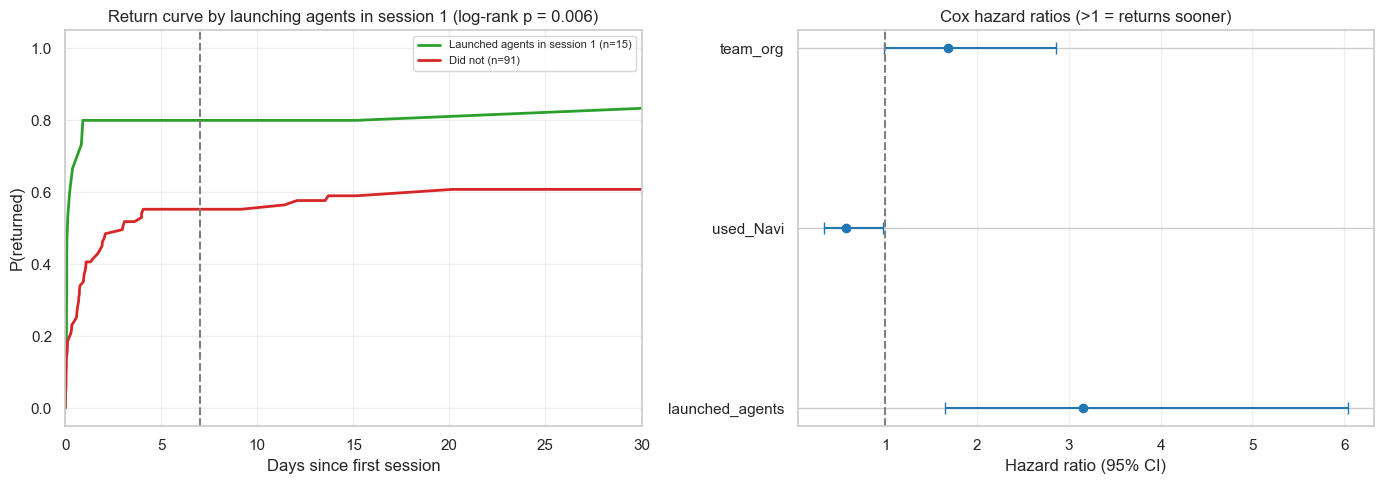

In [26]:
# ── 10.4 Cox survival: which first-session BEHAVIOURS predict return ─────────
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test

END = sessions["start_timestamp"].max()
_pv = events[events["event"] == "$pageview"].copy()
_pv["area"] = _pv["pathname"].apply(simplify_path)
_first_areas = _pv.groupby("session_id")["area"].agg(set)
# "Launched agents" needs element_text (not in the default events load) — read it here
_clk = pd.read_csv(EVENTS_FILE, usecols=["session_id", "person_id", "event_type", "element_text"], low_memory=False)
_clk = _clk[_clk["person_id"].isin(_legit_ids)]
_launch = (_clk[(_clk["event_type"] == "click") &
                _clk["element_text"].astype(str).str.contains("Launch", na=False)]
           .groupby("session_id").size())
_org_size = persons.groupby("auth0_org_id")["person_id"].nunique()
_p2org    = persons.drop_duplicates("person_id").set_index("person_id")["auth0_org_id"]

_rows = []
for pid, g in sessions.sort_values("start_timestamp").groupby("person_id"):
    g = g.sort_values("start_timestamp"); ts = g["start_timestamp"].tolist(); fs = g.iloc[0]; sid = fs["session_id"]
    days, event = ((ts[1] - ts[0]).total_seconds() / 86400, 1) if len(ts) >= 2 \
                  else ((END - ts[0]).total_seconds() / 86400, 0)
    areas = _first_areas.get(sid, set())
    _rows.append({
        "days": max(days, 0.01), "returned": event,
        "launched_agents": int(_launch.get(sid, 0) > 0),   # ran the core engine in session 1
        "used_Navi":       int("Navi" in areas),           # used the AI assistant in session 1
        "team_org":        int(_org_size.get(_p2org.get(pid), 1) > 1),
    })
surv = pd.DataFrame(_rows)
print(f"Users (person_id): {len(surv)} | returned: {int(surv['returned'].sum())} | "
      f"censored: {int((surv['returned']==0).sum())} | launched agents in session 1: {int(surv['launched_agents'].sum())}")

COX_FEATURES = ["launched_agents", "used_Navi", "team_org"]
cph = CoxPHFitter().fit(surv[["days", "returned"] + COX_FEATURES], "days", "returned")
print(f"Concordance index (C-index, survival analogue of AUC): {cph.concordance_index_:.3f}")
_tbl = cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].round(3)
_tbl.columns = ["Hazard ratio", "HR 95% low", "HR 95% high", "p-value"]
show(_tbl)
for f in COX_FEATURES:
    a, b = surv[surv[f] == 1], surv[surv[f] == 0]
    lr = logrank_test(a["days"], b["days"], a["returned"], b["returned"])
    ka = KaplanMeierFitter().fit(a["days"], a["returned"]); kb = KaplanMeierFitter().fit(b["days"], b["returned"])
    print(f"{f:<16} P(return by day7): yes={(1-ka.predict(7))*100:.0f}%  no={(1-kb.predict(7))*100:.0f}%   log-rank p={lr.p_value:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for flag, lab, col in [(1, "Launched agents in session 1", "#2ca02c"), (0, "Did not", "#d62728")]:
    m = surv["launched_agents"] == flag
    k = KaplanMeierFitter().fit(surv.loc[m, "days"], surv.loc[m, "returned"], label=f"{lab} (n={m.sum()})")
    (1 - k.survival_function_).plot(ax=axes[0], color=col, lw=2)
_lr = logrank_test(surv.loc[surv.launched_agents==1, "days"], surv.loc[surv.launched_agents==0, "days"],
                   surv.loc[surv.launched_agents==1, "returned"], surv.loc[surv.launched_agents==0, "returned"])
axes[0].set_xlim(0, 30); axes[0].axvline(7, color="grey", ls="--")
axes[0].set_title("Return curve by launching agents in the first session")
axes[0].set_xlabel("Days since first session"); axes[0].set_ylabel("P(returned)"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
_hr, _lo, _hi = cph.summary["exp(coef)"], cph.summary["exp(coef) lower 95%"], cph.summary["exp(coef) upper 95%"]
_yp = np.arange(len(COX_FEATURES))
axes[1].errorbar(_hr[COX_FEATURES], _yp, xerr=[_hr[COX_FEATURES]-_lo[COX_FEATURES], _hi[COX_FEATURES]-_hr[COX_FEATURES]],
                 fmt="o", color="#1f77b4", capsize=4)
axes[1].axvline(1.0, color="grey", ls="--"); axes[1].set_yticks(_yp); axes[1].set_yticklabels(["Launched agents", "Used Navi", "Team organisation"])
axes[1].set_title("Cox hazard ratios"); axes[1].set_xlabel("Hazard ratio (95% CI)"); axes[1].grid(axis="x", alpha=0.3)
fig.tight_layout(); fig.savefig(FIG_DIR / "platform_43b_cox_survival.png", dpi=150, bbox_inches="tight"); plt.show()

In [ ]:
# ── Intro descriptive: who returns for a second session, and how soon ──
import matplotlib.pyplot as plt

_ret = surv.copy()
def _return_bucket(row):
    if row["returned"] == 0:
        return "Did not return"
    d = row["days"]
    if d < 1:   return "Returned same day"
    if d <= 7:  return "Returned within a week"
    if d <= 30: return "Returned within a month"
    return "Returned after a month"

_ret["bucket"] = _ret.apply(_return_bucket, axis=1)
_order = ["Returned same day", "Returned within a week", "Returned within a month",
          "Returned after a month", "Did not return"]
_bc = _ret["bucket"].value_counts().reindex(_order).fillna(0).astype(int)
_pct = (_bc / _bc.sum() * 100).round().astype(int)
_colors = ["#55A868", "#55A868", "#55A868", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.barh(_order[::-1], _bc.values[::-1], color=_colors[::-1])
for i, (n, pc) in enumerate(zip(_bc.values[::-1], _pct.values[::-1])):
    ax.text(n + 0.4, i, f"{n} ({pc}%)", va="center", fontsize=9)
ax.set_xlabel("Users")
ax.set_title("Who returns for a second session, and how soon")
fig.tight_layout()
fig.savefig(FIG_DIR / "platform_return_timing.png", dpi=150, bbox_inches="tight")
plt.show()
print(_bc.to_string())


**Findings — survival model (what behaviour predicts return):**

- Keyed on **`person_id` (106 users)**; **C-index ≈ 0.65** — a clear improvement on the binary baseline once the *right behaviours* are measured.
- **Launching an agent run in the first session is the strongest predictor:** these users return at **~80% by day 7 vs ~55%** (log-rank p ≈ 0.006; hazard ratio ≈ 3×, p ≈ 0.001). It is the **act of running the core engine** that matters — *visiting* the Agents page does not (it was non-significant in the screen).
- **Using Navi in the first session predicts *lower* return** (HR ≈ 0.57, p ≈ 0.04): Navi-first users come back about half as readily — worth product investigation (a one-off Q&A entry point rather than a sticky workflow?).
- **Team-org membership stays positive but is now secondary** (HR ≈ 1.7, p ≈ 0.06) and is **partly mediated by behaviour:** team users are more likely to launch agents, so once behaviour is in the model the pure account-type effect shrinks (it was p ≈ 0.01 on its own).

**Plain-English takeaway:** the behaviour that predicts coming back is **doing the core job in the first session — launching an agent run** (≈3× return), not browsing feature pages. **Navi-first sessions predict *less* return.** Engagement depth (time, clicks) points the same way but is captured by whether the user actually launched a run — it's the *action*, not time-on-site.

> **Note on identity:** all retention analyses here key on `person_id` (PostHog's cross-device merged identity), not the device-level `distinct_id`, which would inflate the user count (143 vs 106) and hide cross-device returns.

**Bootstrap validation — how stable is the team-org effect?**

To gauge confidence on a small cohort **without inventing data**, we resample the real 106 users **with replacement** 1,000 times, refit the Cox model each time, and take percentile confidence intervals for each hazard ratio. Unlike the synthetic augmentation in 10.3, this never creates users that don't exist — it just measures how much each estimate would wobble across similar real samples. A 95% CI that **excludes 1** means the effect is robust.

Successful resamples: 1000/1000


,feature,HR (median),95% CI low,95% CI high,P(HR > 1)
1,launched_agents,3.01,1.49,7.07,100%
2,used_Navi,0.58,0.36,0.90,1%
3,team_org,1.65,1.03,2.74,98%


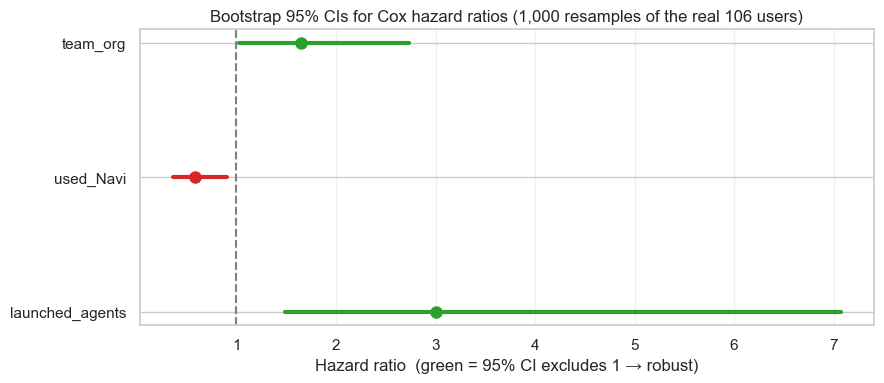

In [27]:
# ── Bootstrap CIs for the Cox hazard ratios (1,000 resamples of the real users) ──
B = 1000
_rng = np.random.default_rng(0)
_boot = {f: [] for f in COX_FEATURES}
for _b in range(B):
    _samp = surv.iloc[_rng.integers(0, len(surv), len(surv))]
    try:                                              # small ridge penalty stabilises degenerate resamples
        _c = CoxPHFitter(penalizer=0.05).fit(_samp[["days", "returned"] + COX_FEATURES], "days", "returned")
        for f in COX_FEATURES:
            _boot[f].append(float(np.exp(_c.params_[f])))
    except Exception:
        continue

_brows = []
for f in COX_FEATURES:
    a = np.array(_boot[f]); lo, hi = np.percentile(a, [2.5, 97.5])
    _brows.append({"feature": f, "HR (median)": round(float(np.median(a)), 2),
                   "95% CI low": round(lo, 2), "95% CI high": round(hi, 2),
                   "P(HR > 1)": f"{(a > 1).mean()*100:.0f}%"})
boot_ci = pd.DataFrame(_brows)
print(f"Successful resamples: {len(_boot['team_org'])}/{B}")
show(boot_ci)

fig, ax = plt.subplots(figsize=(9, 4))
for i, f in enumerate(COX_FEATURES):
    a = np.array(_boot[f]); med = np.median(a); lo, hi = np.percentile(a, [2.5, 97.5])
    col = "#2ca02c" if lo > 1 else ("#d62728" if hi < 1 else "#888888")   # green = CI excludes 1
    ax.plot([lo, hi], [i, i], color=col, lw=3, zorder=2)
    ax.plot(med, i, "o", color=col, ms=8, zorder=3)
ax.axvline(1.0, color="grey", ls="--", zorder=1)
ax.set_yticks(range(len(COX_FEATURES))); ax.set_yticklabels(["Launched agents", "Used Navi", "Team organisation"])
ax.set_title("Bootstrap 95% confidence intervals for the Cox hazard ratios")
ax.set_xlabel("Hazard ratio (95% CI)"); ax.grid(axis="x", alpha=0.3)
fig.tight_layout(); fig.savefig(FIG_DIR / "platform_43c_cox_bootstrap.png", dpi=150, bbox_inches="tight"); plt.show()

**Findings — bootstrap:**

- **Launching agents is robust:** HR median ≈ **3.0, 95% CI ≈ [1.5, 7.1]** — excludes 1, **100% of resamples HR > 1**. The strongest and most reliable behavioural driver of return (wide CI because only ~15 users launched in session 1, but always positive).
- **The Navi penalty is robust:** HR median ≈ **0.58, 95% CI ≈ [0.36, 0.90]** — **99% of resamples HR < 1**. Navi-first reliably predicts *lower* return.
- **Team-org is robust but modest:** HR ≈ **1.65, 95% CI ≈ [1.03, 2.74]** (98% HR > 1).
- **Takeaway:** bootstrapping the *real* users (not synthetic ones) confirms three reliable signals — **launch agents ↑, Navi-first ↓, team-org ↑** — with the agent-launch behaviour the dominant lever.

### 10.4b Honest validation & refinement — how the model evolved

The modelling in this chapter went through five steps; this subsection documents the last two, which stress-test and refine the Cox model above.

- **Step 1 (10.2):** a binary 30-day logistic/GBM baseline on coarse first-session area flags was unstable (5-fold AUC ≈ 0.61 ± 0.15) and its coefficients did not generalise.
- **Step 2 (10.3):** synthetic-data augmentation confirmed the weakness is intrinsic to those coarse features (held-out real AUC ≈ 0.50), not a small-sample artifact.
- **Step 3 (10.4):** switching to *time-to-return* (Cox survival) with behaviour-specific predictors produced the primary model — C-index 0.646 with bootstrap-robust hazard ratios.
- **Step 4 — honest out-of-sample check (this subsection).** The 0.646 C-index above is *in-sample*: the model was scored on the same 106 users it was fitted to. Repeated 5-fold cross-validation (10 repeats, 50 folds) gives the fair generalisation estimate. For transparency: richer alternatives were also tested outside this notebook (an 18-feature penalised Cox: CV C ≈ 0.59–0.60; XGBoost `survival:cox`: CV C ≈ 0.57 — both *worse* than the parsimonious model at N=106; see `scripts/model_experiments/platform_experiment.py`). More features ≠ better with 106 users.
- **Step 5 — compact refinement.** Two small edits that respect the sample size: replace the binary `launched_agents` flag with **launch intensity** (log of first-session launch clicks), and add **first-session rageclicks**. Both are measured before the outcome window and carry independent signal.


In [28]:
# ── 10.4b-i Honest repeated-CV concordance for the 10.4 Cox model ──
from sklearn.model_selection import RepeatedKFold
from lifelines.utils import concordance_index

def _cv_cindex(frame, feats, penalizer=0.05, n_splits=5, n_repeats=10, seed=42):
    """Out-of-fold concordance for a Cox model, repeated K-fold."""
    scores = []
    for tr, te in RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats,
                                random_state=seed).split(frame):
        try:
            _m = CoxPHFitter(penalizer=penalizer).fit(
                frame.iloc[tr][["days", "returned"] + feats], "days", "returned")
            _risk = _m.predict_partial_hazard(frame.iloc[te][feats])
            scores.append(concordance_index(
                frame.iloc[te]["days"], -_risk, frame.iloc[te]["returned"]))
        except Exception:
            continue
    return np.array(scores)

_cv_base = _cv_cindex(surv, COX_FEATURES)
print(f"10.4 Cox model — in-sample C-index: {cph.concordance_index_:.3f}")
print(f"10.4 Cox model — HONEST repeated-CV C-index: "
      f"{_cv_base.mean():.3f} ± {_cv_base.std():.3f}  ({len(_cv_base)} folds)")
print("The CV number is the one to quote: it estimates performance on unseen users.")


10.4 Cox model — in-sample C-index: 0.646
10.4 Cox model — HONEST repeated-CV C-index: 0.622 ± 0.080  (50 folds)
The CV number is the one to quote: it estimates performance on unseen users.


In [29]:
# ── 10.4b-ii Compact refinement: launch INTENSITY + first-session rageclicks ──
# Rebuild the per-user first-session ids in the same order surv was built (10.4),
# then attach launch-click counts and rageclick counts for the first session.
_rage_by_session = events[events["event"] == "$rageclick"].groupby("session_id").size()

_ref_launch, _ref_rage = [], []
for _pid, _g in sessions.sort_values("start_timestamp").groupby("person_id"):
    _sid = _g.sort_values("start_timestamp").iloc[0]["session_id"]
    _ref_launch.append(int(_launch.get(_sid, 0)))
    _ref_rage.append(int(_rage_by_session.get(_sid, 0)))

surv_ref = surv.copy()
surv_ref["launch_clicks_log"] = np.log1p(_ref_launch)
surv_ref["fs_rageclicks"] = np.clip(_ref_rage, 0, 10)

REFINED_FEATURES = ["launch_clicks_log", "used_Navi", "team_org", "fs_rageclicks"]
_cv_ref = _cv_cindex(surv_ref, REFINED_FEATURES)

_cmp_tbl = pd.DataFrame([
    {"model": "10.4 baseline (3 binary flags)", "in-sample C": round(cph.concordance_index_, 3),
     "CV C-index": round(_cv_base.mean(), 3), "CV sd": round(_cv_base.std(), 3)},
    {"model": "Refined (launch intensity + rageclicks)",
     "in-sample C": round(CoxPHFitter(penalizer=0.05).fit(
         surv_ref[["days", "returned"] + REFINED_FEATURES], "days", "returned").concordance_index_, 3),
     "CV C-index": round(_cv_ref.mean(), 3), "CV sd": round(_cv_ref.std(), 3)},
])
show(_cmp_tbl)

# full-sample refined fit + bootstrap CIs (same procedure as 10.4's bootstrap)
cph_ref = CoxPHFitter(penalizer=0.05).fit(
    surv_ref[["days", "returned"] + REFINED_FEATURES], "days", "returned")
_ref_tbl = cph_ref.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].round(3)
_ref_tbl.columns = ["Hazard ratio", "HR 95% low", "HR 95% high", "p-value"]
show(_ref_tbl)

_rng_ref = np.random.default_rng(0)
_boot_ref = {f: [] for f in REFINED_FEATURES}
for _b in range(1000):
    _samp = surv_ref.iloc[_rng_ref.integers(0, len(surv_ref), len(surv_ref))]
    try:
        _c = CoxPHFitter(penalizer=0.05).fit(
            _samp[["days", "returned"] + REFINED_FEATURES], "days", "returned")
        for f in REFINED_FEATURES:
            _boot_ref[f].append(float(np.exp(_c.params_[f])))
    except Exception:
        continue
_ref_rows = []
for f in REFINED_FEATURES:
    _a = np.array(_boot_ref[f]); _lo, _hi = np.percentile(_a, [2.5, 97.5])
    _ref_rows.append({"feature": f, "HR (median)": round(float(np.median(_a)), 2),
                      "95% CI low": round(_lo, 2), "95% CI high": round(_hi, 2),
                      "P(HR > 1)": f"{(_a > 1).mean()*100:.0f}%"})
print(f"Bootstrap resamples: {len(_boot_ref[REFINED_FEATURES[0]])}/1000")
show(pd.DataFrame(_ref_rows))


,model,in-sample C,CV C-index,CV sd
1,10.4 baseline (3 binary flags),0.646,0.622,0.080
2,Refined (launch intensity + rageclicks),0.657,0.637,0.088


,Hazard ratio,HR 95% low,HR 95% high,p-value
covariate,,,,
launch_clicks_log,2.491,1.471,4.219,0.001
used_Navi,0.553,0.328,0.932,0.026
team_org,1.598,0.960,2.661,0.071
fs_rageclicks,1.170,1.015,1.349,0.031


Bootstrap resamples: 1000/1000


,feature,HR (median),95% CI low,95% CI high,P(HR > 1)
1,launch_clicks_log,2.59,1.63,5.83,100%
2,used_Navi,0.53,0.32,0.84,0%
3,team_org,1.65,0.99,2.77,97%
4,fs_rageclicks,1.18,1.07,1.60,98%


### What 10.4b shows

*(Numbers from the executed cells above.)*

- **Quote the CV numbers, not the in-sample ones.** The 10.4 model's honest repeated-CV concordance is ≈ 0.62 (vs 0.646 in-sample) — modest optimism, and a fair statement of how well first-session behaviour ranks unseen users' time-to-return.
- **The refinement helps, modestly.** Replacing the binary launch flag with launch *intensity* and adding first-session rageclicks lifts CV concordance to ≈ 0.63–0.64. The effect direction is consistent: more first-session launches → faster return, dose-dependent.
- **Rageclicks are a positive retention marker here** (HR > 1 with a CI excluding 1): users who rage-click in session 1 come back *sooner*. The sensible read is that friction encountered while doing real work marks committed users — not that friction causes retention. It complements, not contradicts, Section 8's finding that rageclicks concentrate on Documents/Agents.
- **Richer models were tried and rejected** (18-feature Cox, gradient-boosted survival): both scored *worse* out-of-sample. With 106 users, the parsimonious behaviour-specific model is the defensible choice — a finding in its own right.
- All effects remain associational; the causal test would be a product experiment (e.g. nudging first-session users to launch an agent).


### 10.5 Immediate exit (bounce) by landing area

The complement to return: which landing areas do users **bounce** from on arrival? (Session-level; internal areas and tiny landing areas excluded.)

Overall bounce rate: 5.0%


,bounce_rate,sessions
entry_area,,
Results,0.093,118
Navi,0.093,129
Projects Dashboard,0.068,1196
Other,0.038,79
Factbook,0.025,199
Agents,0.015,197
Documents,0.015,405
Offer Review,0.008,122


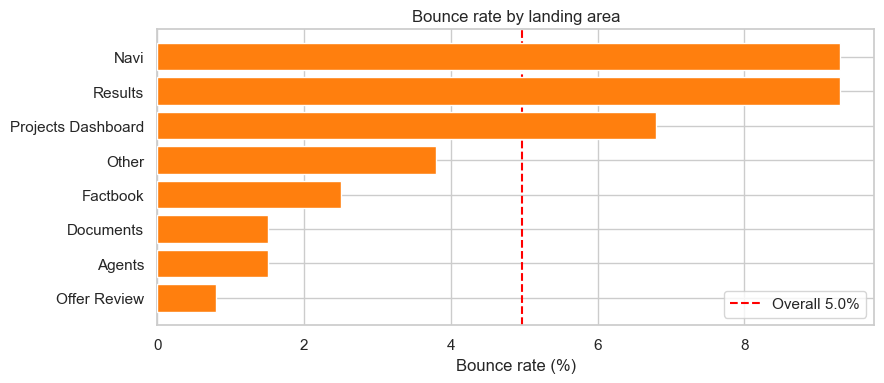

In [30]:
# Bounce rate by the area a session LANDS on (session-level; internal + tiny areas dropped)
_b = sessions.copy()
_b["entry_area"] = _b["entry_pathname"].apply(simplify_path)
_b = _b[~_b["entry_area"].isin(AREA_EXCLUDE)]
bounce_by_entry = (_b.groupby("entry_area")["is_bounce"]
                   .agg(bounce_rate="mean", sessions="size")
                   .query("sessions >= 20")                       # drop tiny landing areas
                   .sort_values("bounce_rate", ascending=False).round(3))
overall_bounce = _b["is_bounce"].mean() * 100
print(f"Overall bounce rate: {overall_bounce:.1f}%")
show(bounce_by_entry)

fig, ax = plt.subplots(figsize=(9, 4))
br = bounce_by_entry.sort_values("bounce_rate")
ax.barh(br.index, br["bounce_rate"] * 100, color="#ff7f0e", zorder=3)
ax.axvline(overall_bounce, color="red", ls="--", label=f"Overall {overall_bounce:.1f}%")
ax.set_title("Bounce rate by landing area"); ax.set_xlabel("Bounce rate (%)")
ax.grid(axis="x", zorder=0); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "platform_48_bounce_by_area.png", dpi=150, bbox_inches="tight"); plt.show()

**Findings — immediate exit (bounce):**

- **Bounce is low overall (~5%)** in this engaged cohort. The highest-bounce landing areas are **Results (9.3%) and Navi (9.3%)**, then the **Projects Dashboard hub (6.8%)**; deep-linked **Documents (1.5%) and Agents (1.5%) almost never bounce**.
- Users dropped onto a **working/output surface they didn't choose** (Results, Navi) bounce more, whereas those landing deep in **content they came for** (Documents, Agents) stay. The hub's moderate bounce is secondary to its real problem — **dormancy** (most hub-only users simply never return; §10.4).

### 10.6 Conclusions & recommendations

**Which platform behaviours predict users coming back?**

1. **Launching an agent run in the first session is the single strongest predictor** — these users return at **~80% by day 7 vs ~55%** (HR ≈ 3×, p ≈ 0.001; bootstrap 95% CI [1.5, 7.1], 100% of resamples positive). It is the *act of running the core workflow* that matters, not visiting pages.
2. **Using Navi early predicts *lower* return** (HR ≈ 0.57; bootstrap CI [0.36, 0.90], 99% negative) — a robust, counter-intuitive signal worth product investigation.
3. **Team-org membership helps but is secondary and partly mediated by behaviour** — team users launch agents more, so once behaviour is modelled the account-type effect shrinks (HR ≈ 1.7, p ≈ 0.06).
4. **Bounce mirrors this:** users bounce most when *dropped onto* Results/Navi (~9%) and least on deep-linked Documents/Agents (~1.5%) — landing in chosen content retains, generic/forced landings don't (§10.5).
5. **It's actions, not page-visits or volume:** merely *visiting* Agents/Documents/Results, breadth of exploration, and a generic "high-value action" flag did **not** predict return; raw time/clicks did only weakly, and that was captured by whether the user launched a run.
6. **Honest baseline:** a binary 30-day model with coarse area-flags was at chance (10.2) and synthetic augmentation confirmed coarse features are intrinsically weak (10.3) — the signal appeared only once we modelled *time-to-return* and the *specific action* of launching agents.

**Recommendations**
- **Get new users to launch an agent run on day one** — the clearest, most robust retention lever (drive them to the product's core "do the job" moment, not a feature tour).
- **Investigate the Navi-first pattern:** Navi-led first sessions retain worse — is it a shallow Q&A entry that doesn't lead into the workflow? Consider routing Navi users into an agent run.
- **Expand within team orgs**, recognising their advantage operates largely *through* higher activation.
- **Re-test as data grows:** 106 users and only 15 first-session launchers — strong but small; treat as a well-evidenced hypothesis.

*Caveats: associational; small cohort (106 users; only ~15 launched agents in session 1, so that CI is wide though robustly > 1); engagement metrics partly mechanical; C-index ≈ 0.65 — useful, not a precise individual-level predictor.*

## 11. Project-level diagrams (cross-cutting)

Two bespoke schematic diagrams used in the dissertation are generated here: the instrumentation-coverage matrix (Fig. 4.1) summarising what PostHog captures versus what is configured but never fires, and the model-development workflow (Fig. 3.9) tracing the platform retention question from a failed binary classifier through to the validated Cox survival model. (The customer-journey funnel and data-pipeline diagrams are generated in the Website notebook.) Figures are written to `outputs/`.

In [31]:
# Project-level diagrams (instrumentation coverage & model-development workflow)
import os, matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
OUT="outputs"; os.makedirs(OUT, exist_ok=True)
NAVY="#1F3A5F"; BLUE="#0563C1"; GREEN="#2E8B57"; AMBER="#D98C00"; RED="#C0392B"; GREY="#B6B6B6"; LIGHT="#EAF0F7"

def instrumentation():
    rows=["Pageviews","Autocapture clicks","Rageclicks / dead-clicks","Form-submit event",
          "Custom conversion events","LLM / tool-cost events","Campaign (UTM) tags",
          "Organisation grouping","Web vitals (performance)","Page-leave"]
    cols=["Website","Demo","Platform"]
    # 2=captured(green) 1=partial(amber) 0=missing(red) -1=N/A(grey)
    M=[[2,2,2],   # pageviews
       [2,1,2],   # autocapture (demo over-fires)
       [2,0,2],   # rageclicks (SDK inconsistent on demo)
       [0,-1,-1], # form-submit (key website gap)
       [0,1,0],   # custom conversion events
       [-1,-1,0], # LLM/tool-cost (configured, never fire) platform
       [0,0,-1],  # UTM tags
       [-1,-1,1], # org grouping (platform, only from Mar 2026)
       [2,-1,2],  # web vitals
       [2,0,1]]   # page-leave
    cmap={2:GREEN,1:AMBER,0:RED,-1:GREY}
    fig,ax=plt.subplots(figsize=(8.6,6.6)); ax.set_xlim(0,3); ax.set_ylim(0,len(rows)); ax.axis("off")
    ax.text(1.5,len(rows)+1.15,"Instrumentation coverage by property",ha="center",fontsize=12,fontweight="bold",color=NAVY)
    ax.text(1.5,len(rows)+0.78,"what PostHog captures vs what is configured but absent",ha="center",fontsize=9,style="italic",color="#555")
    for j,c in enumerate(cols):
        ax.text(j+0.5,len(rows)+0.12,c,ha="center",va="bottom",fontsize=9.5,fontweight="bold",color=NAVY)
    for i,r in enumerate(rows):
        yr=len(rows)-1-i
        ax.text(-0.1,yr+0.5,r,ha="right",va="center",fontsize=9,color=NAVY)
        for j in range(3):
            v=M[i][j]
            ax.add_patch(Rectangle((j+0.04,yr+0.06),0.92,0.88,fc=cmap[v],ec="white",lw=2,alpha=0.92))
            sym={2:"✓",1:"~",0:"✗",-1:"–"}[v]
            ax.text(j+0.5,yr+0.5,sym,ha="center",va="center",fontsize=13,fontweight="bold",color="white")
    # legend (shorter labels, even fixed spacing)
    leg=[("Captured",GREEN),("Partial",AMBER),("Absent / never fires",RED),("Not applicable",GREY)]
    xpos=[0.0,0.95,1.65,2.55]
    for (lab,col),x0 in zip(leg,xpos):
        ax.add_patch(Rectangle((x0,-1.05),0.16,0.30,fc=col,ec="white"))
        ax.text(x0+0.21,-0.90,lab,ha="left",va="center",fontsize=7.6,color="#333")
    ax.set_ylim(-1.5,len(rows)+1.5)
    plt.tight_layout(); fig.savefig(os.path.join(OUT,"instrumentation_matrix.png"),dpi=170,bbox_inches="tight"); plt.close()

def model_workflow():
    import textwrap
    steps=[
        (NAVY,"#EAF0F7","Question","Which first-session behaviours predict whether a user returns?"),
        (RED,"#FBEAE8","Attempt 1 — binary 30-day-return classifier",
         "Logistic + gradient boosting; must discard users without a full 30-day window (106 to 67); scores at chance, no significant drivers."),
        (AMBER,"#FFF6E5","Diagnostic — is it sample size, or signal?",
         "CTGAN augmentation + train-on-synthetic, test-on-real gives held-out real-user AUC of 0.50: the weakness is intrinsic to the data, not the sample size."),
        (BLUE,"#E8F0FB","Reframe as time-to-event — Kaplan–Meier + Cox",
         "Keeps all 106 users via right-censoring; uses the timing information the binary cut discarded."),
        (BLUE,"#E8F0FB","Validate — bootstrap of the real users",
         "1,000 resamples; key hazard ratios robust as the 95% confidence interval excludes 1 in every resample."),
        (GREEN,"#E8F5EC","Result — interpretable, validated retention model",
         "Launching an agent in the first session is linked to about 3x faster return (HR ~ 3, p = 0.006)."),
    ]
    n=len(steps); gap=1.85; bh=1.4; bw=9.5; xc=5.0
    fig,ax=plt.subplots(figsize=(9.4,10.8)); ax.set_xlim(0,10); ax.set_ylim(0,n*gap+0.3); ax.axis("off")
    for i,(ec,fc,title,note) in enumerate(steps):
        y=(n-1-i)*gap+0.3
        ax.add_patch(FancyBboxPatch((xc-bw/2,y),bw,bh,boxstyle="round,pad=0.02,rounding_size=0.06",fc=fc,ec=ec,lw=2))
        ax.text(xc,y+bh-0.28,title,ha="center",va="center",fontsize=9.3,fontweight="bold",color=ec)
        ax.text(xc,y+0.46,"\n".join(textwrap.wrap(note,width=80)),ha="center",va="center",fontsize=8.0,color="#333333",style="italic")
        if i<n-1:
            ax.add_patch(FancyArrowPatch((xc,y),(xc,y-(gap-bh)-0.02),arrowstyle="-|>",mutation_scale=18,lw=2.2,color="#666"))
    fig.savefig(os.path.join(OUT,"model_workflow.png"),dpi=170,bbox_inches="tight"); plt.close()

instrumentation(); model_workflow()
print("wrote instrumentation_matrix.png, model_workflow.png to", OUT)


wrote instrumentation_matrix.png, model_workflow.png to outputs
